In [105]:
import rasterio
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt

from joblib import Parallel, delayed #并行运算的库

In [106]:
# 修改工作路径
import os
# print(os.getcwd())
os.chdir('D:/0_PhdData/0_Paper/4_Global_P/4.2_Global_P_Calculation/') # 修改工作路径

全球数据

In [107]:
# Global土壤-气候数据读取

dt = pd.read_csv('./5_Model_data/Global_data/Global_data.csv')

# 使用每列的平均值填补 NA 值
dt = dt.apply(lambda x: x.fillna(x.mean()), axis=0)

In [108]:
# Soil-土壤变量
Sample = './3_Processed_data/1_Grid/1_Soil/0_Olsen_P/Olsen-P_10km.tif' #(mg/kg)

with rasterio.open(Sample) as src:
    band1 = src.read(1)  # 读取第一个波段
    nodata_value = src.nodata #读取Nodata
    transform = src.transform
    crs = src.crs
    nodata_value = src.nodata

    # 创建掩码，将NoData值屏蔽
    band1 = np.ma.masked_equal(band1, nodata_value)

    # 计算栅格的边界坐标
    height, width = band1.shape
    x = np.linspace(transform[2], transform[2] + transform[0] * width, width + 1)
    y = np.linspace(transform[5], transform[5] + transform[4] * height, height + 1)
    x, y = np.meshgrid(x, y)

In [109]:
# 创建一个空的 DataFrame 来存储结果
result_df = pd.DataFrame()

# 获取列名
column_names = dt.columns.tolist()

for name in column_names:
    ESPT = np.array(dt[name])
    # 将计算结果恢复为原始的2维数组，并恢复NA值
    band1_restored = np.full(band1.shape, -9999, dtype=band1.dtype)
    band1_restored[~np.ma.masked_equal(band1, -9999).mask] = ESPT


    # 将Nodata数值转为NA以来绘图
    lssss = np.ma.masked_equal(band1_restored, nodata_value)[::1, ::1]

    lssss_df = pd.DataFrame(lssss)  # 转为 DataFrame

    # 去除 NaN 转为一列
    lssss_flat = lssss.compressed()  # 压缩成一维数组（去除掩码值）
    lssss_series = pd.Series(lssss_flat, name=name)  # 转为 Pandas Series

    # 将结果合并到总的 DataFrame
    result_df[name] = lssss_series

1. 构建风险区划分

In [6]:
# 读取数据
ASPT_RICE = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Rice.csv')
print('Rice:',ASPT_RICE.mean())
ASPT_MAIZE = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Maize.csv')
print('Maize:',ASPT_MAIZE.mean())
ASPT_WHEAT = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Wheat.csv')
print('Wheat:',ASPT_WHEAT.mean())
ASPT_CASH = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(cash).csv')
print('Cash:',ASPT_CASH.mean())
ASPT_CEREALS = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(cereals).csv')
print('Cereals:',ASPT_CEREALS.mean())
ASPT_OIL = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(oil).csv')
print('Oil:',ASPT_OIL.mean())
ASPT_PULSES = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(pulses).csv')
print('Pulses:',ASPT_PULSES.mean())
ASPT_ROOTS = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(roots).csv')
print('Roots:',ASPT_ROOTS.mean())
ASPT_VEG = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(veg).csv')
print('Veg:',ASPT_VEG.mean())
ASPT_MEAN = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_MEAN.csv')
print('Other:',ASPT_MEAN.mean())

Rice: 0    10.644172
dtype: float64
Maize: 0    11.119592
dtype: float64
Wheat: 0    12.09792
dtype: float64
Cash: 0    26.268502
dtype: float64
Cereals: 0    12.06283
dtype: float64
Oil: 0    17.762744
dtype: float64
Pulses: 0    15.006734
dtype: float64
Roots: 0    23.437983
dtype: float64
Veg: 0    27.349579
dtype: float64
Other: p_threshold    16.673189
dtype: float64


In [7]:
# 读取数据
ESPT_RICE = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Rice.csv')
print('Rice:',ESPT_RICE.mean())
ESPT_MAIZE = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Maize.csv')
print('Maize:',ESPT_MAIZE.mean())
ESPT_WHEAT = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Wheat.csv')
print('Wheat:',ESPT_WHEAT.mean())
ESPT_OTHER = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
print('Other:',ESPT_OTHER.mean())
ESPT_MEAN = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_MEAN.csv')
print('Mean:',ESPT_MEAN.mean())

Rice: 0    56.579478
dtype: float64
Maize: 0    53.841205
dtype: float64
Wheat: 0    55.286608
dtype: float64
Other: 0    53.296129
dtype: float64
Mean: p_threshold    54.406727
dtype: float64


In [8]:
# 全球Olsen-P
SPT = pd.DataFrame({'OP': dt['OP']})
# ASPT
SPT['ASPT_RICE'] = ASPT_RICE
SPT['ASPT_MAIZE'] = ASPT_MAIZE
SPT['ASPT_WHEAT'] = ASPT_WHEAT
SPT['ASPT_CASH'] = ASPT_CASH
SPT['ASPT_CEREALS'] = ASPT_CEREALS
SPT['ASPT_OIL'] = ASPT_OIL
SPT['ASPT_PULSES'] = ASPT_PULSES
SPT['ASPT_ROOTS'] = ASPT_ROOTS
SPT['ASPT_VEG'] = ASPT_VEG
SPT['ASPT_MEAN'] = ASPT_MEAN
# ESPT
SPT['ESPT_RICE'] = ESPT_RICE
SPT['ESPT_MAIZE'] = ESPT_MAIZE
SPT['ESPT_WHEAT'] = ESPT_WHEAT
SPT['ESPT_OTHER'] = ESPT_OTHER
SPT['ESPT_MEAN'] = ESPT_MEAN

In [9]:
# 定义分类条件
def classify(op, aspt, espt):
    if espt <= aspt:
        if op < espt * 2:
            return 0
        else:
            return 1        
    else:
        if op <= aspt:
            return 2
        elif aspt <= op < espt:
            return 3
        else:
            if op >= aspt * 2:
                return 4
            else:
                return 5

In [10]:
SPT['OP'] = dt['OP']
# 应用分类逻辑
SPT['RISK'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_MEAN'], row['ESPT_MEAN']), axis=1)
SPT['RISK_RICE'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_RICE'], row['ESPT_RICE']), axis=1)
SPT['RISK_MAIZE'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_MAIZE'], row['ESPT_MAIZE']), axis=1)
SPT['RISK_WHEAT'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_WHEAT'], row['ESPT_WHEAT']), axis=1)
SPT['RISK_CASH'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_CASH'], row['ESPT_OTHER']), axis=1)
SPT['RISK_CEREALS'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_CEREALS'], row['ESPT_OTHER']), axis=1)
SPT['RISK_OIL'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_OIL'], row['ESPT_OTHER']), axis=1)
SPT['RISK_PULSES'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_PULSES'], row['ESPT_OTHER']), axis=1)
SPT['RISK_ROOTS'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_ROOTS'], row['ESPT_OTHER']), axis=1)
SPT['RISK_VEG'] = SPT.apply(lambda row: classify(row['OP'], row['ASPT_VEG'], row['ESPT_OTHER']), axis=1)

In [11]:
SPT

,OP,ASPT_RICE,ASPT_MAIZE,ASPT_WHEAT,ASPT_CASH,ASPT_CEREALS,ASPT_OIL,ASPT_PULSES,ASPT_ROOTS,ASPT_VEG,...,RISK,RISK_RICE,RISK_MAIZE,RISK_WHEAT,RISK_CASH,RISK_CEREALS,RISK_OIL,RISK_PULSES,RISK_ROOTS,RISK_VEG
0,25.432394,11.636728,9.638656,14.662455,30.557385,12.610966,20.584289,19.604150,29.405941,31.366337,...,2,3,3,3,2,3,3,3,2,2
1,25.482624,9.739029,8.723742,16.633440,30.259575,12.590711,19.604108,19.604143,29.405941,31.366337,...,2,3,3,3,2,3,3,3,2,2
2,25.491611,11.903957,10.782195,13.662902,31.491235,12.663722,21.564333,19.604009,30.386139,30.386139,...,2,3,3,3,2,3,3,3,2,2
3,25.361048,13.621976,10.607109,13.674899,31.215552,12.599842,18.501013,19.603545,29.405941,30.386139,...,2,3,3,3,2,3,3,3,2,2
4,25.928701,12.682722,8.933955,20.567620,28.422772,11.834969,17.792245,17.643389,21.564376,26.465347,...,2,3,3,3,2,3,3,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832822,4.680000,8.937590,9.916487,11.739441,25.484347,10.749971,17.724794,18.581173,28.425743,30.386139,...,2,2,2,2,2,2,2,2,2,2
832823,4.680000,9.893594,10.778339,13.639041,28.424232,10.818650,16.774038,19.466413,27.445545,29.405941,...,2,2,2,2,2,2,2,2,2,2
832824,4.680000,9.706383,9.955400,11.741312,25.411370,10.820412,17.725090,18.633590,28.425743,30.386139,...,2,2,2,2,2,2,2,2,2,2
832825,4.680000,8.956072,10.723563,11.813734,25.485024,10.894224,16.663149,18.627206,28.425742,30.386139,...,2,2,2,2,2,2,2,2,2,2


2. 推荐施肥

1 读取产产量 (kg/ha)

In [12]:
import re

In [13]:
# 指定文件夹路径
folder_path = './3_Processed_data/1_Grid/0_1_YIELD'

# 获取所有 .tif 文件的路径
variables_yield = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.tif')]

# 提取 Y_ACOF 部分的列表
column_names_yield = []

for path in variables_yield:
    # 使用正则表达式提取 `Y_XXXX` 部分
    match = re.search(r'Y_[A-Z]+', path)
    if match:
        column_names_yield.append(match.group())

In [14]:
###  循环变量数值到数据框中
dt_yield = pd.DataFrame()

for file_path, column_name in zip(variables_yield, column_names_yield):
    print(file_path)
    with rasterio.open(file_path) as src:
        band = src.read(1)  # 读取第一个波段
        band_data = np.ma.masked_equal(band, -1).compressed() #掩盖nodata，并转为一行array()
        dt_yield[column_name] = band_data
# 只去掉列名开头的 Y_
dt_yield.columns = [col[2:] if col.startswith("Y_") else col for col in dt_yield.columns]


./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_ACOF_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_BANA_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_BARL_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_BEAN_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_CASS_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_CHIC_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_CNUT_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_COCO_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_COTT_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_COWP_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_GROU_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_LENT_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_MAIZ_A.tif
./3_Processed_data/1_Grid/0_1_YIELD\spam2010V2r0_global_Y_OCER_A.tif
./3_Processed_data/1_Grid/0_1_YIEL

2 读取耕地面积(ha)

In [15]:
# 指定文件夹路径
folder_path = './3_Processed_data/1_Grid/0_2_PHYS'

# 获取所有 .tif 文件的路径
variables_phy = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.tif')]

# 提取 Y_ACOF 部分的列表
column_names_phy = []

for path in variables_phy:
    # 使用正则表达式提取 `Y_XXXX` 部分
    match = re.search(r'A_[A-Z]+', path)
    if match:
        column_names_phy.append(match.group())

In [16]:
###  循环变量数值到数据框中
dt_phy = pd.DataFrame()

for file_path, column_name in zip(variables_phy, column_names_phy):
    print(file_path)
    with rasterio.open(file_path) as src:
        band = src.read(1)  # 读取第一个波段
        band_data = np.ma.masked_equal(band, -1).compressed() #掩盖nodata，并转为一行array()
        dt_phy[column_name] = band_data
# 去掉列名开头的 Y_
dt_phy.columns = [col[2:] if col.startswith("A_") else col for col in dt_yield.columns]

./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_ACOF_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_BANA_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_BARL_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_BEAN_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_CASS_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_CHIC_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_CNUT_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_COCO_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_COTT_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_COWP_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_GROU_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_LENT_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_MAIZ_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_global_A_OCER_A.tif
./3_Processed_data/1_Grid/0_2_PHYS\spam2010V2r0_

3 读取播种面积

In [17]:
# 指定文件夹路径
folder_path = './3_Processed_data/1_Grid/0_3_HARV'

# 获取所有 .tif 文件的路径
variables_har = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.tif')]

# 提取 Y_ACOF 部分的列表
column_names_har = []

for path in variables_har:
    # 使用正则表达式提取 `Y_XXXX` 部分
    match = re.search(r'H_[A-Z]+', path) 
    if match:
        column_names_har.append(match.group())

In [18]:
###  循环变量数值到数据框中
dt_har = pd.DataFrame()

for file_path, column_name in zip(variables_har, column_names_har):
    print(file_path)
    with rasterio.open(file_path) as src:
        band = src.read(1)  # 读取第一个波段
        band_data = np.ma.masked_equal(band, -1).compressed() #掩盖nodata，并转为一行array()
        dt_har[column_name] = band_data
# 去掉列名开头的 Y_
dt_har.columns = [col[2:] if col.startswith("H_") else col for col in dt_yield.columns]

./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_ACOF_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_BANA_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_BARL_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_BEAN_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_CASS_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_CHIC_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_CNUT_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_COCO_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_COTT_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_COWP_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_GROU_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_LENT_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_MAIZ_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_global_H_OCER_A.tif
./3_Processed_data/1_Grid/0_3_HARV\spam2010V2r0_

In [19]:
dt_har_crop = pd.DataFrame({
    'rice_phy': dt_har['RICE'],
    'wheat_phy': dt_har['WHEA'],
    'maize_phy': dt_har['MAIZ'],
    'cereals_phy': dt_har[['BARL', 'PMIL', 'SMIL', 'SORG', 'OCER']].sum(axis=1),
    'cash_phy': dt_har[['SUGC', 'SUGB', 'COTT', 'OFIB', 'ACOF', 'RCOF', 'COCO', 'TEAS', 'TOBA', 'REST']].sum(axis=1),
    'pulses_phy': dt_har[['BEAN', 'CHIC', 'COWP', 'PIGE', 'LENT', 'OPUL', 'SOYB', 'GROU']].sum(axis=1),
    'roots_phy': dt_har[['POTA', 'SWPO', 'YAMS', 'CASS', 'ORTS']].sum(axis=1),
    'veg_phy': dt_har[['VEGE','CNUT', 'BANA', 'PLNT', 'TROF', 'TEMF']].sum(axis=1),
    'oil_phy': dt_har[['OILP', 'SUNF', 'RAPE', 'SESA', 'OOIL']].sum(axis=1),
    'total_phy':dt_har.sum(axis=1),
})
dt_har_crop

,rice_phy,wheat_phy,maize_phy,cereals_phy,cash_phy,pulses_phy,roots_phy,veg_phy,oil_phy,total_phy
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,0.0,1.3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.9
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,1.1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.9
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.9
...,...,...,...,...,...,...,...,...,...,...
832822,0.0,0.0,0.0,0.0,0.0,0.0,1.8,0.0,0.0,1.8
832823,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.4
832824,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
832825,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,1.5


In [20]:
dt_har_crop.sum(numeric_only=True)/1000000

rice_phy        160.732192
wheat_phy       220.717744
maize_phy       164.569600
cereals_phy     154.017280
cash_phy        118.858000
pulses_phy      203.679248
roots_phy        55.110056
veg_phy         123.414840
oil_phy          99.891824
total_phy      1300.990592
dtype: float64

In [21]:
# 1. 先算每列总和
col_sum = dt_har_crop.sum(numeric_only=True)

# 2. total_phy 这一列的总和
total_phy_sum = dt_har_crop['total_phy'].sum()

# 3. 各列总和 / total_phy总和
ratio = col_sum / total_phy_sum

print(ratio)

rice_phy       0.123546
wheat_phy      0.169654
maize_phy      0.126496
cereals_phy    0.118385
cash_phy       0.091360
pulses_phy     0.156557
roots_phy      0.042360
veg_phy        0.094862
oil_phy        0.076781
total_phy      1.000000
dtype: float32


In [22]:
dt_yieldzz_crop = pd.DataFrame({
    'rice': dt_yield['RICE'],
    'maize': dt_yield['MAIZ'],
    'wheat': dt_yield['WHEA'],
    'other_cereal': dt_yield[['BARL', 'PMIL', 'SMIL', 'SORG', 'OCER']].sum(axis=1),
    'other_rhizome': dt_yield[['POTA', 'SWPO', 'YAMS', 'CASS', 'ORTS']].sum(axis=1),
    'other_legume': dt_yield[['BEAN', 'CHIC', 'COWP', 'PIGE', 'LENT', 'OPUL', 'SOYB', 'GROU']].sum(axis=1),
    'other_vf': dt_yield[['VEGE', 'CNUT', 'BANA', 'PLNT', 'TROF', 'TEMF']].sum(axis=1),
    'other_oil': dt_yield[['OILP', 'SUNF', 'RAPE', 'SESA', 'OOIL']].sum(axis=1),
    'other_cash': dt_yield[['SUGC', 'SUGB', 'COTT', 'OFIB', 'ACOF', 'RCOF', 'COCO', 'TEAS', 'TOBA', 'REST']].sum(axis=1)
})
dt_yieldzz_crop.sum()/10000000

rice              100.882189
maize             217.944934
wheat             123.836454
other_cereal      258.579098
other_rhizome    1739.904819
other_legume      249.548826
other_vf         2248.399667
other_oil         173.175539
other_cash       1501.251686
dtype: float64

In [24]:
crop_other_columns = ['ACOF', 'BANA', 'BARL', 'BEAN', 'CASS', 'CHIC', 'CNUT', 'COCO', 'COTT',
       'COWP', 'GROU', 'LENT', 'OCER', 'OFIB', 'OILP', 'OOIL', 'OPUL',
       'ORTS', 'PIGE', 'PLNT', 'PMIL', 'POTA', 'RAPE', 'RCOF', 'REST',
       'SESA', 'SMIL', 'SORG', 'SOYB', 'SUGB', 'SUGC', 'SUNF', 'SWPO', 'TEAS',
       'TEMF', 'TOBA', 'TROF', 'VEGE', 'YAMS']

In [25]:
# 计算P带走量
P_removal = (dt_yield * dt_Pcontent_grain + dt_yield * dt_Pcontent_ratio * dt_Pcontent_straw)/1000
P_removal_total = P_removal*dt_har
P_removal_total_crop = pd.DataFrame({
    'rice_premoval':P_removal_total['RICE'],
    'maize_premoval':P_removal_total['MAIZ'],
    'wheat_premoval':P_removal_total['WHEA'],
    'other_cereal':P_removal_total[['BARL', 'PMIL', 'SMIL', 'SORG', 'OCER']].sum(axis=1),
    'other_rhizome':P_removal_total[['POTA', 'SWPO', 'YAMS', 'CASS', 'ORTS']].sum(axis=1),
    'other_legume':P_removal_total[['BEAN', 'CHIC', 'COWP', 'PIGE', 'LENT', 'OPUL', 'SOYB', 'GROU']].sum(axis=1),
    'other_vf':P_removal_total[['VEGE','CNUT', 'BANA', 'PLNT', 'TROF', 'TEMF']].sum(axis=1),
    'other_oil':P_removal_total[['OILP', 'SUNF', 'RAPE', 'SESA', 'OOIL']].sum(axis=1),
    'other_cash':P_removal_total[['SUGC', 'SUGB', 'COTT', 'OFIB', 'ACOF', 'RCOF', 'COCO', 'TEAS', 'TOBA', 'REST']].sum(axis=1)
})

In [26]:
P_removal_total_crop.sum().sum()/1000000000

15.585827048801544

In [27]:
P_removal_total_crop.sum()/1000000

rice_premoval     1224.750072
maize_premoval    2430.449621
wheat_premoval    2466.910188
other_cereal       857.346887
other_rhizome      496.669185
other_legume      1730.337046
other_vf          2417.029986
other_oil          945.881021
other_cash        3016.453042
dtype: float64

In [28]:
SPT

,OP,ASPT_RICE,ASPT_MAIZE,ASPT_WHEAT,ASPT_CASH,ASPT_CEREALS,ASPT_OIL,ASPT_PULSES,ASPT_ROOTS,ASPT_VEG,...,RISK,RISK_RICE,RISK_MAIZE,RISK_WHEAT,RISK_CASH,RISK_CEREALS,RISK_OIL,RISK_PULSES,RISK_ROOTS,RISK_VEG
0,25.432394,11.636728,9.638656,14.662455,30.557385,12.610966,20.584289,19.604150,29.405941,31.366337,...,2,3,3,3,2,3,3,3,2,2
1,25.482624,9.739029,8.723742,16.633440,30.259575,12.590711,19.604108,19.604143,29.405941,31.366337,...,2,3,3,3,2,3,3,3,2,2
2,25.491611,11.903957,10.782195,13.662902,31.491235,12.663722,21.564333,19.604009,30.386139,30.386139,...,2,3,3,3,2,3,3,3,2,2
3,25.361048,13.621976,10.607109,13.674899,31.215552,12.599842,18.501013,19.603545,29.405941,30.386139,...,2,3,3,3,2,3,3,3,2,2
4,25.928701,12.682722,8.933955,20.567620,28.422772,11.834969,17.792245,17.643389,21.564376,26.465347,...,2,3,3,3,2,3,3,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832822,4.680000,8.937590,9.916487,11.739441,25.484347,10.749971,17.724794,18.581173,28.425743,30.386139,...,2,2,2,2,2,2,2,2,2,2
832823,4.680000,9.893594,10.778339,13.639041,28.424232,10.818650,16.774038,19.466413,27.445545,29.405941,...,2,2,2,2,2,2,2,2,2,2
832824,4.680000,9.706383,9.955400,11.741312,25.411370,10.820412,17.725090,18.633590,28.425743,30.386139,...,2,2,2,2,2,2,2,2,2,2
832825,4.680000,8.956072,10.723563,11.813734,25.485024,10.894224,16.663149,18.627206,28.425742,30.386139,...,2,2,2,2,2,2,2,2,2,2


In [29]:
P_removal_total_crop['OP'] = SPT['OP']
# 农学阈值
P_removal_total_crop['ASPT_RICE'] = SPT['ASPT_RICE']
P_removal_total_crop['ASPT_MAIZE'] = SPT['ASPT_MAIZE']
P_removal_total_crop['ASPT_WHEAT'] = SPT['ASPT_WHEAT']
P_removal_total_crop['ASPT_CASH'] = SPT['ASPT_CASH']
P_removal_total_crop['ASPT_CEREALS'] = SPT['ASPT_CEREALS']
P_removal_total_crop['ASPT_OIL'] = SPT['ASPT_OIL']
P_removal_total_crop['ASPT_PULSES'] = SPT['ASPT_PULSES']
P_removal_total_crop['ASPT_ROOTS'] = SPT['ASPT_ROOTS']
P_removal_total_crop['ASPT_VEG'] = SPT['ASPT_VEG']
# 环境阈值
P_removal_total_crop['ESPT_RICE'] = SPT['ESPT_RICE']
P_removal_total_crop['ESPT_MAIZE'] = SPT['ESPT_MAIZE']
P_removal_total_crop['ESPT_WHEAT'] = SPT['ESPT_WHEAT']
P_removal_total_crop['ESPT_OTHER'] = SPT['ESPT_OTHER']
# 风险评估结果
P_removal_total_crop['RISK_RICE'] = SPT['RISK_RICE']
P_removal_total_crop['RISK_MAIZE'] = SPT['RISK_MAIZE']
P_removal_total_crop['RISK_WHEAT'] = SPT['RISK_WHEAT']
P_removal_total_crop['RISK_CASH'] = SPT['RISK_CASH']
P_removal_total_crop['RISK_CEREALS'] = SPT['RISK_CEREALS']
P_removal_total_crop['RISK_OIL'] = SPT['RISK_OIL']
P_removal_total_crop['RISK_PULSES'] = SPT['RISK_PULSES']
P_removal_total_crop['RISK_ROOTS'] = SPT['RISK_ROOTS']
P_removal_total_crop['RISK_VEG'] = SPT['RISK_VEG']

In [30]:
(P_removal_total_crop < 0).sum()

rice_premoval     0
maize_premoval    0
wheat_premoval    0
other_cereal      0
other_rhizome     0
other_legume      0
other_vf          0
other_oil         0
other_cash        0
OP                0
ASPT_RICE         0
ASPT_MAIZE        0
ASPT_WHEAT        0
ASPT_CASH         0
ASPT_CEREALS      0
ASPT_OIL          0
ASPT_PULSES       0
ASPT_ROOTS        0
ASPT_VEG          0
ESPT_RICE         0
ESPT_MAIZE        0
ESPT_WHEAT        0
ESPT_OTHER        0
RISK_RICE         0
RISK_MAIZE        0
RISK_WHEAT        0
RISK_CASH         0
RISK_CEREALS      0
RISK_OIL          0
RISK_PULSES       0
RISK_ROOTS        0
RISK_VEG          0
dtype: int64

In [31]:
P_removal_total_crop

,rice_premoval,maize_premoval,wheat_premoval,other_cereal,other_rhizome,other_legume,other_vf,other_oil,other_cash,OP,...,ESPT_OTHER,RISK_RICE,RISK_MAIZE,RISK_WHEAT,RISK_CASH,RISK_CEREALS,RISK_OIL,RISK_PULSES,RISK_ROOTS,RISK_VEG
0,0.0,0.0,0.0,0.0,0.000000,0.0,8.649599,0.0,0.0,25.432394,...,56.851614,3,3,3,2,3,3,3,2,2
1,0.0,0.0,0.0,0.0,0.000000,0.0,5.988184,0.0,0.0,25.482624,...,71.554358,3,3,3,2,3,3,3,2,2
2,0.0,0.0,0.0,0.0,0.000000,0.0,7.318892,0.0,0.0,25.491611,...,54.890904,3,3,3,2,3,3,3,2,2
3,0.0,0.0,0.0,0.0,0.000000,0.0,5.988184,0.0,0.0,25.361048,...,61.853073,3,3,3,2,3,3,3,2,2
4,0.0,0.0,0.0,0.0,0.000000,0.0,5.988184,0.0,0.0,25.928701,...,65.673313,3,3,3,2,3,3,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832822,0.0,0.0,0.0,0.0,21.974921,0.0,0.000000,0.0,0.0,4.680000,...,50.970035,2,2,2,2,2,2,2,2,2
832823,0.0,0.0,0.0,0.0,4.883316,0.0,0.000000,0.0,0.0,4.680000,...,62.543838,2,2,2,2,2,2,2,2,2
832824,0.0,0.0,0.0,0.0,12.208290,0.0,0.000000,0.0,0.0,4.680000,...,49.990046,2,2,2,2,2,2,2,2,2
832825,0.0,0.0,0.0,0.0,18.312435,0.0,0.000000,0.0,0.0,4.680000,...,49.009829,2,2,2,2,2,2,2,2,2


计算推荐施肥

In [32]:
# rice
def calculate_pfer_rice(row):
    if row["RISK_RICE"] == 1:
        return 0
    elif row["RISK_RICE"] == 0:
        return row["rice_premoval"] * (1 + (row["ESPT_RICE"] - row["OP"])/row["ESPT_RICE"])
    elif row["RISK_RICE"] == 2:
        return row["rice_premoval"] * (1 + (row["ASPT_RICE"] - row["OP"])/row["ASPT_RICE"])
    elif row["RISK_RICE"] == 3:
        return row["rice_premoval"]
    elif row["RISK_RICE"] == 4:
        return 0       
    else:
        return row["rice_premoval"] * (1 - (row["OP"] - row["ASPT_RICE"])/row["ASPT_RICE"]) 
    
# maize
def calculate_pfer_maize(row):
    if row["RISK_MAIZE"] == 1:
        return 0
    elif row["RISK_MAIZE"] == 0:
        return row["maize_premoval"] * (1 + (row["ESPT_MAIZE"] - row["OP"])/row["ESPT_MAIZE"])
    elif row["RISK_MAIZE"] == 2:
        return row["maize_premoval"] * (1 + (row["ASPT_MAIZE"] - row["OP"])/row["ASPT_MAIZE"])
    elif row["RISK_MAIZE"] == 3:
        return row["maize_premoval"]
    elif row["RISK_MAIZE"] == 4:
        return 0       
    else:
        return row["maize_premoval"] * (1 - (row["OP"] - row["ASPT_MAIZE"])/row["ASPT_MAIZE"]) 

# wheat
def calculate_pfer_wheat(row):
    if row["RISK_WHEAT"] == 1:
        return 0
    elif row["RISK_WHEAT"] == 0:
        return row["wheat_premoval"] * (1 + (row["ESPT_WHEAT"] - row["OP"])/row["ESPT_WHEAT"])
    elif row["RISK_WHEAT"] == 2:
        return row["wheat_premoval"] * (1 + (row["ASPT_WHEAT"] - row["OP"])/row["ASPT_WHEAT"])
    elif row["RISK_WHEAT"] == 3:
        return row["wheat_premoval"]
    elif row["RISK_WHEAT"] == 4:
        return 0       
    else:
        return row["wheat_premoval"] * (1 - (row["OP"] - row["ASPT_WHEAT"])/row["ASPT_WHEAT"]) 
    
# other_cereal
def calculate_pfer_other_cereal(row):
    if row["RISK_CEREALS"] == 1:
        return 0
    elif row["RISK_CEREALS"] == 0:
        return row["other_cereal"] * (1 + (row["ESPT_OTHER"] - row["OP"]) / row["ESPT_OTHER"])
    elif row["RISK_CEREALS"] == 2:
        return row["other_cereal"] * (1 + (row["ASPT_CEREALS"] - row["OP"]) / row["ASPT_CEREALS"])
    elif row["RISK_CEREALS"] == 3:
        return row["other_cereal"]
    elif row["RISK_CEREALS"] == 4:
        return 0
    else:
        return row["other_cereal"] * (1 - (row["OP"] - row["ASPT_CEREALS"]) / row["ASPT_CEREALS"])


# other_rhizome
def calculate_pfer_other_rhizome(row):
    if row["RISK_ROOTS"] == 1:
        return 0
    elif row["RISK_ROOTS"] == 0:
        return row["other_rhizome"] * (1 + (row["ESPT_OTHER"] - row["OP"]) / row["ESPT_OTHER"])
    elif row["RISK_ROOTS"] == 2:
        return row["other_rhizome"] * (1 + (row["ASPT_ROOTS"] - row["OP"]) / row["ASPT_ROOTS"])
    elif row["RISK_ROOTS"] == 3:
        return row["other_rhizome"]
    elif row["RISK_ROOTS"] == 4:
        return 0
    else:
        return row["other_rhizome"] * (1 - (row["OP"] - row["ASPT_ROOTS"]) / row["ASPT_ROOTS"])


# other_legume
def calculate_pfer_other_legume(row):
    if row["RISK_PULSES"] == 1:
        return 0
    elif row["RISK_PULSES"] == 0:
        return row["other_legume"] * (1 + (row["ESPT_OTHER"] - row["OP"]) / row["ESPT_OTHER"])
    elif row["RISK_PULSES"] == 2:
        return row["other_legume"] * (1 + (row["ASPT_PULSES"] - row["OP"]) / row["ASPT_PULSES"])
    elif row["RISK_PULSES"] == 3:
        return row["other_legume"]
    elif row["RISK_PULSES"] == 4:
        return 0
    else:
        return row["other_legume"] * (1 - (row["OP"] - row["ASPT_PULSES"]) / row["ASPT_PULSES"])


# other_vf
def calculate_pfer_other_vf(row):
    if row["RISK_VEG"] == 1:
        return 0
    elif row["RISK_VEG"] == 0:
        return row["other_vf"] * (1 + (row["ESPT_OTHER"] - row["OP"]) / row["ESPT_OTHER"])
    elif row["RISK_VEG"] == 2:
        return row["other_vf"] * (1 + (row["ASPT_VEG"] - row["OP"]) / row["ASPT_VEG"])
    elif row["RISK_VEG"] == 3:
        return row["other_vf"]
    elif row["RISK_VEG"] == 4:
        return 0
    else:
        return row["other_vf"] * (1 - (row["OP"] - row["ASPT_VEG"]) / row["ASPT_VEG"])


# other_oil
def calculate_pfer_other_oil(row):
    if row["RISK_OIL"] == 1:
        return 0
    elif row["RISK_OIL"] == 0:
        return row["other_oil"] * (1 + (row["ESPT_OTHER"] - row["OP"]) / row["ESPT_OTHER"])
    elif row["RISK_OIL"] == 2:
        return row["other_oil"] * (1 + (row["ASPT_OIL"] - row["OP"]) / row["ASPT_OIL"])
    elif row["RISK_OIL"] == 3:
        return row["other_oil"]
    elif row["RISK_OIL"] == 4:
        return 0
    else:
        return row["other_oil"] * (1 - (row["OP"] - row["ASPT_OIL"]) / row["ASPT_OIL"])


# other_cash
def calculate_pfer_other_cash(row):
    if row["RISK_CASH"] == 1:
        return 0
    elif row["RISK_CASH"] == 0:
        return row["other_cash"] * (1 + (row["ESPT_OTHER"] - row["OP"]) / row["ESPT_OTHER"])
    elif row["RISK_CASH"] == 2:
        return row["other_cash"] * (1 + (row["ASPT_CASH"] - row["OP"]) / row["ASPT_CASH"])
    elif row["RISK_CASH"] == 3:
        return row["other_cash"]
    elif row["RISK_CASH"] == 4:
        return 0
    else:
        return row["other_cash"] * (1 - (row["OP"] - row["ASPT_CASH"]) / row["ASPT_CASH"])

In [33]:
P_fertilizer = pd.DataFrame()
# 应用到 DataFrame
P_fertilizer["Pfer_total_rice"] = P_removal_total_crop.apply(calculate_pfer_rice, axis=1)
P_fertilizer["Pfer_total_maize"] = P_removal_total_crop.apply(calculate_pfer_maize, axis=1)
P_fertilizer["Pfer_total_wheat"] = P_removal_total_crop.apply(calculate_pfer_wheat, axis=1)
P_fertilizer["Pfer_total_cereal"] = P_removal_total_crop.apply(calculate_pfer_other_cereal, axis=1)
P_fertilizer["Pfer_total_rhizome"] = P_removal_total_crop.apply(calculate_pfer_other_rhizome, axis=1)
P_fertilizer["Pfer_total_legume"] = P_removal_total_crop.apply(calculate_pfer_other_legume, axis=1)
P_fertilizer["Pfer_total_vf"] = P_removal_total_crop.apply(calculate_pfer_other_vf, axis=1)
P_fertilizer["Pfer_total_oil"] = P_removal_total_crop.apply(calculate_pfer_other_oil, axis=1)
P_fertilizer["Pfer_total_cash"] = P_removal_total_crop.apply(calculate_pfer_other_cash, axis=1)
P_fertilizer["Pfer_total_all"] = (
    P_fertilizer["Pfer_total_rice"] +P_fertilizer["Pfer_total_maize"]+P_fertilizer["Pfer_total_wheat"]+
    P_fertilizer["Pfer_total_cereal"] +
    P_fertilizer["Pfer_total_rhizome"] +
    P_fertilizer["Pfer_total_legume"] +
    P_fertilizer["Pfer_total_vf"] +
    P_fertilizer["Pfer_total_oil"] +
    P_fertilizer["Pfer_total_cash"]
)

In [34]:
P_fertilizer

,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,Pfer_total_cash,Pfer_total_all
0,0.0,0.0,0.0,0.0,0.000000,0.0,10.285947,0.0,0.0,10.285947
1,0.0,0.0,0.0,0.0,0.000000,0.0,7.111451,0.0,0.0,7.111451
2,0.0,0.0,0.0,0.0,0.000000,0.0,8.497802,0.0,0.0,8.497802
3,0.0,0.0,0.0,0.0,0.000000,0.0,6.978477,0.0,0.0,6.978477
4,0.0,0.0,0.0,0.0,0.000000,0.0,6.109608,0.0,0.0,6.109608
...,...,...,...,...,...,...,...,...,...,...
832822,0.0,0.0,0.0,0.0,40.331903,0.0,0.000000,0.0,0.0,40.331903
832823,0.0,0.0,0.0,0.0,8.933932,0.0,0.000000,0.0,0.0,8.933932
832824,0.0,0.0,0.0,0.0,22.406613,0.0,0.000000,0.0,0.0,22.406613
832825,0.0,0.0,0.0,0.0,33.609920,0.0,0.000000,0.0,0.0,33.609920


# 划分区域

In [35]:
country_shp = pd.read_csv('./5_Model_data/Global_data/Country_shp.csv')
country_shp

,Num,OBJECTID,ECONOMY,INCOME_GRP,Region,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_EN,NAME_ZH
0,1,51,2. Developed region: nonG7,1. High income: OECD,Europe,Europe,Europe,Northern Europe,Europe & Central Asia,Norway,挪威
1,2,51,2. Developed region: nonG7,1. High income: OECD,Europe,Europe,Europe,Northern Europe,Europe & Central Asia,Norway,挪威
2,3,51,2. Developed region: nonG7,1. High income: OECD,Europe,Europe,Europe,Northern Europe,Europe & Central Asia,Norway,挪威
3,4,51,2. Developed region: nonG7,1. High income: OECD,Europe,Europe,Europe,Northern Europe,Europe & Central Asia,Norway,挪威
4,5,51,2. Developed region: nonG7,1. High income: OECD,Europe,Europe,Europe,Northern Europe,Europe & Central Asia,Norway,挪威
...,...,...,...,...,...,...,...,...,...,...,...
832822,832823,3,5. Emerging region: G20,3. Upper middle income,South America,South America,Americas,South America,Latin America & Caribbean,Chile,智利
832823,832824,3,5. Emerging region: G20,3. Upper middle income,South America,South America,Americas,South America,Latin America & Caribbean,Chile,智利
832824,832825,3,5. Emerging region: G20,3. Upper middle income,South America,South America,Americas,South America,Latin America & Caribbean,Chile,智利
832825,832826,3,5. Emerging region: G20,3. Upper middle income,South America,South America,Americas,South America,Latin America & Caribbean,Chile,智利


划分耕地面积

In [36]:
dt_phy_crop = pd.DataFrame({
    'rice_phy': dt_phy['RICE'],
    'wheat_phy': dt_phy['WHEA'],
    'maize_phy': dt_phy['MAIZ'],
    'cereals_phy': dt_phy[['BARL', 'PMIL', 'SMIL', 'SORG', 'OCER']].sum(axis=1),
    'cash_phy': dt_phy[['SUGC', 'SUGB', 'COTT', 'OFIB', 'ACOF', 'RCOF', 'COCO', 'TEAS', 'TOBA', 'REST']].sum(axis=1),
    'pulses_phy': dt_phy[['BEAN', 'CHIC', 'COWP', 'PIGE', 'LENT', 'OPUL', 'SOYB', 'GROU']].sum(axis=1),
    'roots_phy': dt_phy[['POTA', 'SWPO', 'YAMS', 'CASS', 'ORTS']].sum(axis=1),
    'veg_phy': dt_phy[['VEGE','CNUT', 'BANA', 'PLNT', 'TROF', 'TEMF']].sum(axis=1),
    'oil_phy': dt_phy[['OILP', 'SUNF', 'RAPE', 'SESA', 'OOIL']].sum(axis=1),
    'total_phy':dt_phy.sum(axis=1),
    'region':country_shp['Region'],
    'NAME_EN':country_shp['NAME_EN']
})

In [37]:
dt_phy_crop_name = dt_phy_crop.groupby("NAME_EN").sum(numeric_only=True).reset_index()
dt_phy_crop_name

,NAME_EN,rice_phy,wheat_phy,maize_phy,cereals_phy,cash_phy,pulses_phy,roots_phy,veg_phy,oil_phy,total_phy
0,Afghanistan,159521.703125,2.063774e+06,1.378696e+05,2.287653e+05,73624.000000,69409.601562,21629.500000,230144.406250,53573.300781,3.038311e+06
1,Albania,4.900000,7.747620e+04,5.417850e+04,1.741900e+04,11175.000000,21088.900391,9191.000000,64288.800781,36582.199219,2.914045e+05
2,Algeria,215.500000,1.772552e+06,1.886000e+02,1.124548e+06,49417.398438,81135.703125,119761.703125,798289.812500,338417.000000,4.284526e+06
3,American Samoa,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,48.000000,0.000000,2837.899902,3235.099854,0.000000,6.121000e+03
4,Andorra,0.100000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,6.100000,0.000000,6.200000e+00
...,...,...,...,...,...,...,...,...,...,...,...
197,Wallis and Futuna,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,5.700000,0.000000,529.900024,6143.899902,0.000000,6.679500e+03
198,Yemen,0.000000,1.301644e+05,4.498720e+04,6.252262e+05,64402.500000,46801.898438,21370.199219,156570.406250,22821.199219,1.112344e+06
199,Zambia,24036.599609,3.350530e+04,1.053014e+06,8.624190e+04,211416.593750,359160.812500,255024.093750,79581.500000,51396.000000,2.153376e+06
200,Zimbabwe,331.899994,6.669800e+03,1.469130e+06,4.651368e+05,422955.593750,390964.500000,53826.699219,70196.398438,76896.296875,2.956108e+06


In [38]:
dt_phy_crop_region = dt_phy_crop.groupby("region").sum(numeric_only=True).reset_index()
dt_phy_crop_region

,region,rice_phy,wheat_phy,maize_phy,cereals_phy,cash_phy,pulses_phy,roots_phy,veg_phy,oil_phy,total_phy
0,Africa,9.696353e+06,9816878.0,28855740.0,48315276.00,1.965548e+07,31397318.00,23755742.00,15830032.00,1.454709e+07,201869904.0
1,Asia,9.655207e+07,83256216.0,46088520.0,34808240.00,6.176894e+07,67773088.00,17745998.00,77109864.00,3.925218e+07,524355136.0
2,Europe,7.053773e+05,58816312.0,14721513.0,42598060.00,5.187968e+06,5927888.50,6135364.50,11982831.00,2.931432e+07,175389632.0
3,North America,2.015028e+06,26975744.0,42501928.0,9924630.00,9.895969e+06,38514244.00,1311110.25,6226814.00,9.473478e+06,146838944.0
4,Oceania,3.975490e+04,13250579.0,85967.0,5843110.50,8.719718e+05,1825767.75,318306.50,1269458.25,2.064560e+06,25569476.0
5,South America,4.822930e+06,7382005.0,19090658.0,3807997.75,1.918912e+07,48020976.00,3486323.25,6871431.00,3.386669e+06,116058104.0


划分施肥

In [39]:
P_fertilizer['Pfer_total_rice_f'] = P_removal_total_crop['rice_premoval']
P_fertilizer['Pfer_total_maize_f'] = P_removal_total_crop['maize_premoval']
P_fertilizer['Pfer_total_wheat_f'] = P_removal_total_crop['wheat_premoval']

P_fertilizer['Pfer_total_cereal_f'] = P_removal_total_crop['other_cereal']
P_fertilizer['Pfer_total_rhizome_f'] = P_removal_total_crop['other_rhizome']
P_fertilizer['Pfer_total_legume_f'] = P_removal_total_crop['other_legume']
P_fertilizer['Pfer_total_vf_f'] = P_removal_total_crop['other_vf']
P_fertilizer['Pfer_total_oil_f'] = P_removal_total_crop['other_oil']
P_fertilizer['Pfer_total_cash_f'] = P_removal_total_crop['other_cash']

P_fertilizer['Pfer_total_f'] = (
    P_removal_total_crop['rice_premoval'] +
    P_removal_total_crop['maize_premoval'] +
    P_removal_total_crop['wheat_premoval'] +
    P_removal_total_crop['other_cereal'] +
    P_removal_total_crop['other_rhizome'] +
    P_removal_total_crop['other_legume'] +
    P_removal_total_crop['other_vf'] +
    P_removal_total_crop['other_oil'] +
    P_removal_total_crop['other_cash']
)

P_fertilizer['region'] = country_shp['Region']
P_fertilizer['NAME_EN'] = country_shp['NAME_EN']

P_fertilizer['RISK'] = SPT['RISK']
P_fertilizer['RISK_RICE'] = SPT['RISK_RICE']
P_fertilizer['RISK_MAIZE'] = SPT['RISK_MAIZE']
P_fertilizer['RISK_WHEAT'] = SPT['RISK_WHEAT']
P_fertilizer['RISK_CEREALS'] = SPT['RISK_CEREALS']
P_fertilizer['RISK_ROOTS'] = SPT['RISK_ROOTS']
P_fertilizer['RISK_PULSES'] = SPT['RISK_PULSES']
P_fertilizer['RISK_VEG'] = SPT['RISK_VEG']
P_fertilizer['RISK_OIL'] = SPT['RISK_OIL']
P_fertilizer['RISK_CASH'] = SPT['RISK_CASH']

# 定义映射字典
risk_mapping = {
    0: 'Deficient and risk',
    1: 'Deficient and risk',
    2: 'Deficient',
    3: 'Optimal',
    4: 'Risk',
    5: 'Risk'
}

# 需要修改的列
risk_columns = [
    'RISK',
    'RISK_RICE',
    'RISK_MAIZE',
    'RISK_WHEAT',
    'RISK_CEREALS',
    'RISK_ROOTS',
    'RISK_PULSES',
    'RISK_VEG',
    'RISK_OIL',
    'RISK_CASH'
]

# 批量替换
P_fertilizer[risk_columns] = P_fertilizer[risk_columns].replace(risk_mapping)

P_fertilizer['Optimal'] = 'Optimal'
P_fertilizer

,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,Pfer_total_cash,Pfer_total_all,...,RISK_RICE,RISK_MAIZE,RISK_WHEAT,RISK_CEREALS,RISK_ROOTS,RISK_PULSES,RISK_VEG,RISK_OIL,RISK_CASH,Optimal
0,0.0,0.0,0.0,0.0,0.000000,0.0,10.285947,0.0,0.0,10.285947,...,Optimal,Optimal,Optimal,Optimal,Deficient,Optimal,Deficient,Optimal,Deficient,Optimal
1,0.0,0.0,0.0,0.0,0.000000,0.0,7.111451,0.0,0.0,7.111451,...,Optimal,Optimal,Optimal,Optimal,Deficient,Optimal,Deficient,Optimal,Deficient,Optimal
2,0.0,0.0,0.0,0.0,0.000000,0.0,8.497802,0.0,0.0,8.497802,...,Optimal,Optimal,Optimal,Optimal,Deficient,Optimal,Deficient,Optimal,Deficient,Optimal
3,0.0,0.0,0.0,0.0,0.000000,0.0,6.978477,0.0,0.0,6.978477,...,Optimal,Optimal,Optimal,Optimal,Deficient,Optimal,Deficient,Optimal,Deficient,Optimal
4,0.0,0.0,0.0,0.0,0.000000,0.0,6.109608,0.0,0.0,6.109608,...,Optimal,Optimal,Optimal,Optimal,Optimal,Optimal,Deficient,Optimal,Deficient,Optimal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832822,0.0,0.0,0.0,0.0,40.331903,0.0,0.000000,0.0,0.0,40.331903,...,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Optimal
832823,0.0,0.0,0.0,0.0,8.933932,0.0,0.000000,0.0,0.0,8.933932,...,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Optimal
832824,0.0,0.0,0.0,0.0,22.406613,0.0,0.000000,0.0,0.0,22.406613,...,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Optimal
832825,0.0,0.0,0.0,0.0,33.609920,0.0,0.000000,0.0,0.0,33.609920,...,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Deficient,Optimal


In [42]:
import pandas as pd

summary_df = (
    P_fertilizer.groupby(['region', 'RISK_RICE'])['Pfer_total_rice']
    .sum().div(1_000_000).reset_index()
    .rename(columns={'RISK_RICE': 'RISK'})
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_MAIZE'])['Pfer_total_maize']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_MAIZE': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_WHEAT'])['Pfer_total_wheat']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_WHEAT': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_CEREALS'])['Pfer_total_cereal']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_CEREALS': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_ROOTS'])['Pfer_total_rhizome']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_ROOTS': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_PULSES'])['Pfer_total_legume']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_PULSES': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_VEG'])['Pfer_total_vf']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_VEG': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_OIL'])['Pfer_total_oil']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_OIL': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'RISK_CASH'])['Pfer_total_cash']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'RISK_CASH': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_rice_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_maize_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_wheat_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_cereal_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_rhizome_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_legume_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_vf_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_oil_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
    
    .merge(
        P_fertilizer.groupby(['region', 'Optimal'])['Pfer_total_cash_f']
        .sum().div(1_000_000).reset_index()
        .rename(columns={'Optimal': 'RISK'}),
        on=['region', 'RISK'], how='outer'
    )
)

# 缺失补 0
summary_df = summary_df.fillna(0)

# 补一个 other 汇总列
summary_df['Pfer_total_other'] = (
    summary_df['Pfer_total_cereal'] +
    summary_df['Pfer_total_rhizome'] +
    summary_df['Pfer_total_legume'] +
    summary_df['Pfer_total_vf'] +
    summary_df['Pfer_total_oil'] +
    summary_df['Pfer_total_cash']
)

summary_df['Pfer_total_other_f'] = (
    summary_df['Pfer_total_cereal_f'] +
    summary_df['Pfer_total_rhizome_f'] +
    summary_df['Pfer_total_legume_f'] +
    summary_df['Pfer_total_vf_f'] +
    summary_df['Pfer_total_oil_f'] +
    summary_df['Pfer_total_cash_f']
)

# 再补一个总施肥列
summary_df['Pfer_total'] = (
    summary_df['Pfer_total_rice'] +
    summary_df['Pfer_total_maize'] +
    summary_df['Pfer_total_wheat'] +
    summary_df['Pfer_total_other']
)

summary_df['Pfer_total_f'] = (
    summary_df['Pfer_total_rice_f'] +
    summary_df['Pfer_total_maize_f'] +
    summary_df['Pfer_total_wheat_f'] +
    summary_df['Pfer_total_other_f']
)

# 计算全局总和
risk_total = summary_df.groupby("RISK").sum(numeric_only=True).reset_index()
risk_total.insert(0, "region", "Global")

summary_df = pd.concat([summary_df, risk_total], ignore_index=True).fillna(0)

summary_df

,region,RISK,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,...,Pfer_total_cereal_f,Pfer_total_rhizome_f,Pfer_total_legume_f,Pfer_total_vf_f,Pfer_total_oil_f,Pfer_total_cash_f,Pfer_total_other,Pfer_total_other_f,Pfer_total,Pfer_total_f
0,Africa,Deficient,51.758311,186.248892,77.207299,165.649931,209.492027,170.463126,282.857676,88.814084,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1128.546598,0.000000,1443.761100,0.000000
1,Africa,Deficient and risk,0.228354,1.227689,0.390490,4.029704,11.657322,4.464048,22.858230,2.317455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,77.933055,0.000000,79.779587,0.000000
2,Africa,Optimal,6.622624,44.866169,20.371156,32.472386,9.920295,15.258895,11.819666,6.068795,...,149.399552,153.810422,132.820251,197.829429,69.879228,161.278935,83.722635,865.017816,155.582583,1180.023774
3,Africa,Risk,0.011032,0.145523,0.014777,0.084050,0.579565,0.065109,0.469946,0.183415,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.383492,0.000000,2.554824,0.000000
4,Asia,Deficient,444.642690,145.077863,500.781223,100.645942,168.167697,275.651541,1375.331140,722.156808,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4006.703002,0.000000,5097.204778,0.000000
5,Asia,Deficient and risk,1.956612,1.352170,5.013756,0.845269,10.910561,3.456945,109.853665,33.084684,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.224749,0.000000,242.547286,0.000000
6,Asia,Optimal,683.869148,487.590851,664.393001,67.693665,59.106942,157.405040,399.525925,96.188740,...,145.879351,210.928919,416.867166,1707.507832,616.047970,1112.707802,926.508332,4209.939041,2762.361332,7132.137763
7,Asia,Risk,4.166059,1.223117,2.966003,0.276180,1.831520,0.902081,21.194103,2.672645,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.702806,0.000000,42.057985,0.000000
8,Europe,Deficient,0.415341,2.714303,60.077020,17.543944,21.847172,15.101693,139.158911,45.311305,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,295.543865,0.000000,358.750528,0.000000
9,Europe,Deficient and risk,0.003313,0.099947,1.737683,1.610667,7.406213,2.262917,24.677983,5.529929,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,57.233751,0.000000,59.074695,0.000000


ValueError: Incorrect use of keyword argument 'fontsize'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

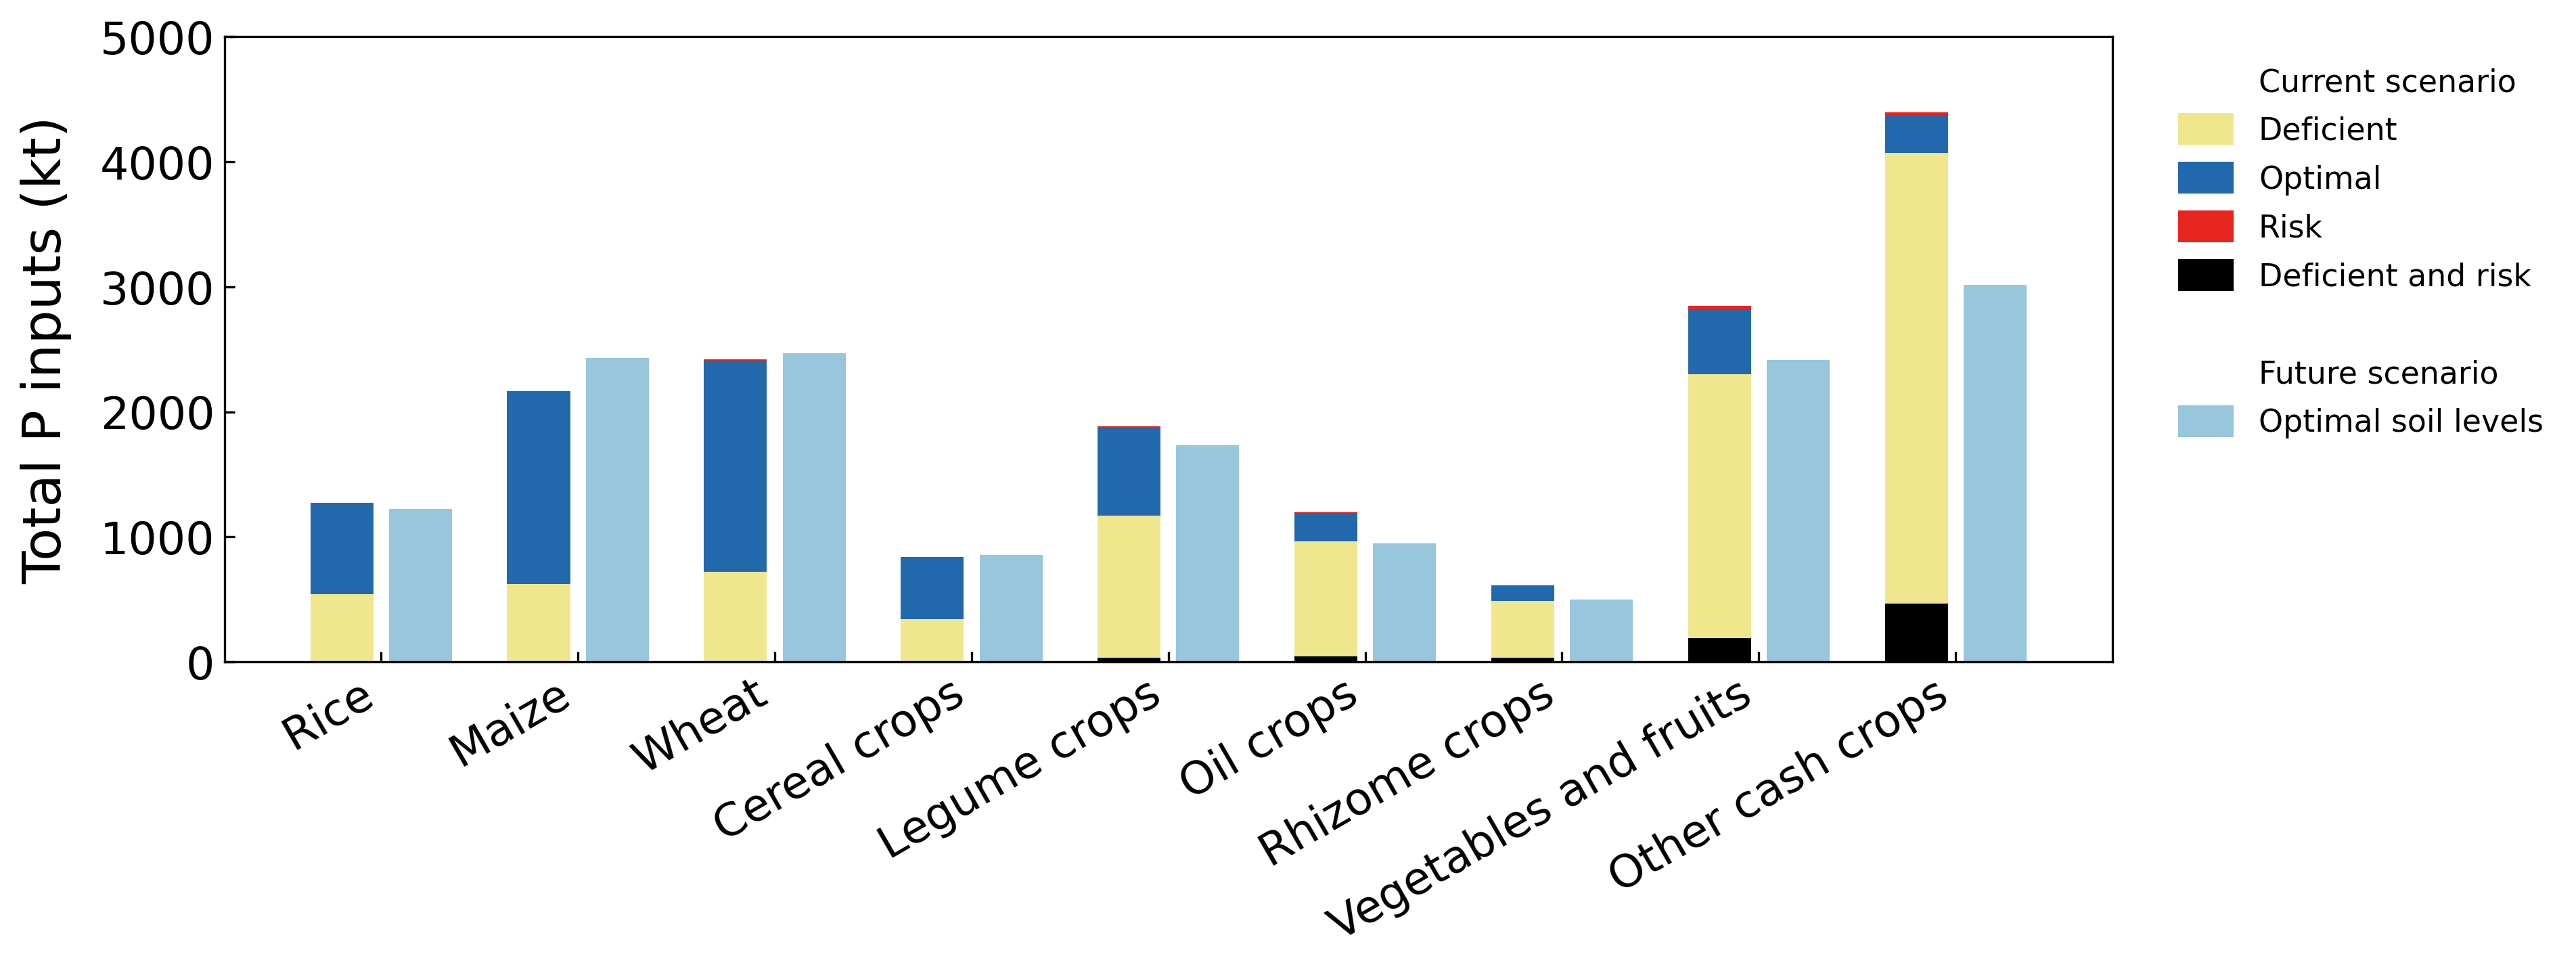

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

region_class = 'Global'
plot_data = summary_df[summary_df['region'] == region_class].copy()

# =========================
# 9个作物类别
# =========================
crop_types = [
    'Pfer_total_rice',
    'Pfer_total_maize',
    'Pfer_total_wheat',
    'Pfer_total_cereal',
    'Pfer_total_legume',
    'Pfer_total_oil',
    'Pfer_total_rhizome',
    'Pfer_total_vf',
    'Pfer_total_cash'
]

crop_types_f = [
    'Pfer_total_rice_f',
    'Pfer_total_maize_f',
    'Pfer_total_wheat_f',
    'Pfer_total_cereal_f',
    'Pfer_total_legume_f',
    'Pfer_total_oil_f',
    'Pfer_total_rhizome_f',
    'Pfer_total_vf_f',
    'Pfer_total_cash_f'
]

crop_labels = [
    'Rice',
    'Maize',
    'Wheat',
    'Cereal crops',
    'Legume crops',
    'Oil crops',
    'Rhizome crops',
    'Vegetables and fruits',
    'Other cash crops'
]

# 固定风险顺序
risk_order = ['Deficient and risk', 'Deficient', 'Optimal', 'Risk']
risk_categories = [r for r in risk_order if r in plot_data['RISK'].unique()]

# 颜色
custom_colors = {
    "Deficient": '#F0E68D',
    "Deficient and risk": 'black',
    "Optimal": '#2168AD',
    "Risk": '#E8241F',
}

# future 统一一个颜色
future_color = "#97C6DD"

# 参数
bar_width = 0.32
spacing_factor = 0.08
x = np.arange(len(crop_types))

# 作图
fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

current_bottom = np.zeros(len(crop_types))
optimal_bottom = np.zeros(len(crop_types))

for risk in risk_categories:
    risk_data = plot_data[plot_data['RISK'] == risk]

    current_values = risk_data[crop_types].sum().values if not risk_data.empty else np.zeros(len(crop_types))
    optimal_values = risk_data[crop_types_f].sum().values if not risk_data.empty else np.zeros(len(crop_types))

    # Current scenario
    ax.bar(
        x - (bar_width + spacing_factor) / 2,
        current_values,
        bar_width,
        color=custom_colors.get(risk, "#999999"),
        bottom=current_bottom
    )
    current_bottom += current_values

    # Future scenario
    ax.bar(
        x + (bar_width + spacing_factor) / 2,
        optimal_values,
        bar_width,
        color=future_color,
        bottom=optimal_bottom
    )
    optimal_bottom += optimal_values

# 坐标轴
ax.set_xticks(x)
ax.set_xticklabels(crop_labels, rotation=30, ha='right')
ax.set_ylabel('Total P inputs (kt)', fontsize=19, labelpad=10)
ax.tick_params(labelsize=16, direction='in')

ymax = max(current_bottom.max(), optimal_bottom.max())
ax.set_ylim(0, ymax * 1.12)

# =========================
# 自定义图例
# =========================
legend_handles = [
    Patch(facecolor='none', edgecolor='none', label='Current scenario'),
    Patch(facecolor=custom_colors["Deficient"], edgecolor='none', label='Deficient'),
    Patch(facecolor=custom_colors["Optimal"], edgecolor='none', label='Optimal'),
    Patch(facecolor=custom_colors["Risk"], edgecolor='none', label='Risk'),
    Patch(facecolor=custom_colors["Deficient and risk"], edgecolor='none', label='Deficient and risk'),
    Patch(facecolor='none', edgecolor='none', label=''),
    Patch(facecolor='none', edgecolor='none', label='Future scenario'),
    Patch(facecolor=future_color, edgecolor='none', label='Optimal soil levels')
]

legend = ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=11,
    handlelength=1.8,
    handleheight=1.2
)
ax.set_ylim(0, 5001)
ax.set_yticks(np.arange(0, 5001, 2500), fontsize=25)
# 让两个标题加粗
legend_texts = legend.get_texts()
legend_texts[0].set_fontweight('bold')
legend_texts[6].set_fontweight('bold')

plt.tight_layout()
plt.show()

In [44]:
# 1. 先算这些列的总量
total = plot_data[crop_types].sum().sum()

# 2. 计算每一列占总量的百分比
percent = plot_data[crop_types].sum() / total * 100

print(percent)

Pfer_total_rice        7.217256
Pfer_total_maize      12.278620
Pfer_total_wheat      13.718735
Pfer_total_cereal      4.753857
Pfer_total_legume     10.702406
Pfer_total_oil         6.782089
Pfer_total_rhizome     3.460972
Pfer_total_vf         16.144609
Pfer_total_cash       24.941456
dtype: float64


linshi_region = P_fertilizer.groupby("NAME_EN").agg({
    "Pfer_total": "sum",  
    "region": "first",  # 取该分组的第一个值
}).reset_index()

In [45]:
P_fertilizer_name = P_fertilizer.groupby("NAME_EN").sum(numeric_only=True).reset_index()
P_fertilizer_name

,NAME_EN,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,Pfer_total_cash,...,Pfer_total_rice_f,Pfer_total_maize_f,Pfer_total_wheat_f,Pfer_total_cereal_f,Pfer_total_rhizome_f,Pfer_total_legume_f,Pfer_total_vf_f,Pfer_total_oil_f,Pfer_total_cash_f,Pfer_total_f
0,Afghanistan,1.409499e+06,1.029933e+06,1.973810e+07,1.563298e+06,2.609608e+05,3.608011e+05,3.840368e+06,1.784169e+05,5.741696e+05,...,1.133854e+06,8.561656e+05,1.566092e+07,1.271783e+06,1.745691e+05,2.755190e+05,2.383045e+06,1.161216e+05,3.425084e+05,2.221449e+07
1,Albania,5.033672e+01,1.150384e+06,1.455230e+06,1.473801e+05,2.236233e+05,1.816963e+05,2.765087e+06,3.019242e+05,1.354231e+05,...,5.033672e+01,9.474647e+05,1.149470e+06,1.172452e+05,1.386067e+05,1.307854e+05,1.655732e+06,1.995539e+05,8.170093e+04,4.420609e+06
2,Algeria,6.350547e+02,1.999404e+03,1.088942e+07,5.209403e+06,3.185762e+06,4.401566e+05,1.791755e+07,1.928061e+06,1.425490e+05,...,5.902732e+02,1.465064e+03,9.939425e+06,4.911974e+06,2.119538e+06,3.714170e+05,1.128660e+07,1.347101e+06,8.812766e+04,3.006624e+07
3,American Samoa,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.131191e+04,0.000000e+00,1.421506e+04,0.000000e+00,7.169747e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.997849e+03,0.000000e+00,8.454055e+03,0.000000e+00,4.312389e+01,1.549503e+04
4,Andorra,5.613543e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.153733e+01,0.000000e+00,0.000000e+00,...,5.613543e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.178838e+01,0.000000e+00,0.000000e+00,6.234973e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Wallis and Futuna,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.264454e+03,0.000000e+00,1.899253e+04,0.000000e+00,5.493723e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.526144e+03,0.000000e+00,1.235478e+04,0.000000e+00,3.589390e+01,1.591682e+04
198,Yemen,0.000000e+00,3.374982e+05,1.402824e+06,2.455735e+06,3.127297e+05,7.337157e+05,3.931673e+06,1.184174e+05,1.787361e+05,...,0.000000e+00,2.029574e+05,8.769572e+05,1.585521e+06,1.831959e+05,4.358593e+05,2.124306e+06,6.390972e+04,9.691249e+04,5.569619e+06
199,Zambia,7.867669e+04,6.843876e+06,6.644966e+05,2.015453e+05,8.187945e+05,1.346704e+06,8.855224e+05,7.023139e+04,2.160894e+06,...,8.227826e+04,7.429921e+06,7.398500e+05,2.310234e+05,9.407965e+05,1.659190e+06,8.886663e+05,9.195983e+04,4.896228e+06,1.695991e+07
200,Zimbabwe,1.260126e+03,2.789729e+06,6.143689e+04,5.282531e+05,2.399234e+05,1.043824e+06,8.859142e+05,1.065195e+05,6.359931e+06,...,1.224712e+03,2.754012e+06,6.670728e+04,4.939204e+05,1.870554e+05,9.754828e+05,5.977807e+05,8.538659e+04,4.354916e+06,9.516485e+06


In [46]:
pd.DataFrame(dt_phy_crop_region.sum(numeric_only=True))

,0
rice_phy,1.138315e+08
wheat_phy,1.994977e+08
maize_phy,1.513443e+08
cereals_phy,1.452973e+08
cash_phy,1.165694e+08
pulses_phy,1.934593e+08
roots_phy,5.275285e+07
veg_phy,1.192904e+08
oil_phy,9.803830e+07
total_phy,1.190081e+09


In [47]:
P_fertilizer_region = P_fertilizer.groupby("region").sum(numeric_only=True).reset_index()
P_fertilizer_region

,region,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,Pfer_total_cash,...,Pfer_total_rice_f,Pfer_total_maize_f,Pfer_total_wheat_f,Pfer_total_cereal_f,Pfer_total_rhizome_f,Pfer_total_legume_f,Pfer_total_vf_f,Pfer_total_oil_f,Pfer_total_cash_f,Pfer_total_f
0,Africa,5.862032e+07,2.324883e+08,9.798372e+07,2.022361e+08,2.316492e+08,1.902512e+08,3.180055e+08,9.738375e+07,2.530601e+08,...,4.428203e+07,1.823077e+08,8.841628e+07,1.493996e+08,1.538104e+08,1.328203e+08,1.978294e+08,6.987923e+07,1.612789e+08,1.180024e+09
1,Asia,1.134635e+09,6.352440e+08,1.173154e+09,1.694611e+08,2.400167e+08,4.374156e+08,1.905905e+09,8.541029e+08,1.594238e+09,...,1.107867e+09,7.217732e+08,1.092559e+09,1.458794e+08,2.109289e+08,4.168672e+08,1.707508e+09,6.160480e+08,1.112708e+09,7.132138e+09
2,Europe,7.570746e+06,2.238046e+08,6.930759e+08,2.935739e+08,6.776090e+07,4.907932e+07,2.439303e+08,1.343981e+08,1.895707e+08,...,7.562686e+06,2.666061e+08,7.995419e+08,3.915022e+08,7.766399e+07,5.480612e+07,2.349097e+08,1.589754e+08,2.503230e+08,2.241891e+09
3,North America,2.036954e+07,7.768008e+08,2.891140e+08,9.760952e+07,2.093181e+07,3.885138e+08,2.002638e+08,5.613408e+07,3.451777e+08,...,2.189470e+07,1.014885e+09,3.189192e+08,9.944497e+07,2.010739e+07,5.029478e+08,1.547442e+08,5.609727e+07,2.647421e+08,2.453782e+09
4,Oceania,5.957311e+05,1.268759e+06,8.521835e+07,3.581746e+07,3.391343e+06,1.131982e+07,1.659694e+07,1.518733e+07,6.208524e+07,...,5.962777e+05,1.657344e+06,8.801684e+07,3.608031e+07,2.552129e+06,1.105957e+07,1.371344e+07,1.121576e+07,4.722407e+07,2.121157e+08
5,South America,5.071478e+07,2.952901e+08,8.026340e+07,3.947503e+07,4.646886e+07,8.104078e+08,1.618243e+08,3.857323e+07,1.953404e+09,...,4.254743e+07,2.432206e+08,7.945738e+07,3.504048e+07,3.160633e+07,6.118361e+08,1.083254e+08,3.366540e+07,1.180177e+09,2.365876e+09


In [48]:
P_fertilizer_region.sum()

region                  AfricaAsiaEuropeNorth AmericaOceaniaSouth America
Pfer_total_rice                                         1272505629.222843
Pfer_total_maize                                        2164896584.677643
Pfer_total_wheat                                        2418809447.906183
Pfer_total_cereal                                        838173005.910984
Pfer_total_rhizome                                       610218842.073322
Pfer_total_legume                                       1886987531.645435
Pfer_total_vf                                           2846525693.095315
Pfer_total_oil                                          1195779378.040797
Pfer_total_cash                                         4397535960.247446
Pfer_total_all                                         17631432072.819969
Pfer_total_rice_f                                       1224750072.300641
Pfer_total_maize_f                                      2430449620.871037
Pfer_total_wheat_f                    

In [49]:
# 复制数据框，避免修改原始数据
result_df = P_fertilizer_region.copy()

# 逐列（从第2列开始到第5列）按索引进行除法运算
result_df.iloc[:, 1:6] = P_fertilizer_region.iloc[:, 6:11].values / dt_phy_crop_region.iloc[:, 1:6].values
result_df


,region,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,Pfer_total_cash,...,Pfer_total_rice_f,Pfer_total_maize_f,Pfer_total_wheat_f,Pfer_total_cereal_f,Pfer_total_rhizome_f,Pfer_total_legume_f,Pfer_total_vf_f,Pfer_total_oil_f,Pfer_total_cash_f,Pfer_total_f
0,Africa,19.620901,32.393753,3.374848,5.237682,85.557705,1.902512e+08,3.180055e+08,9.738375e+07,2.530601e+08,...,4.428203e+07,1.823077e+08,8.841628e+07,1.493996e+08,1.538104e+08,1.328203e+08,1.978294e+08,6.987923e+07,1.612789e+08,1.180024e+09
1,Asia,4.530360,22.892042,18.531792,45.800586,131.848974,4.374156e+08,1.905905e+09,8.541029e+08,1.594238e+09,...,1.107867e+09,7.217732e+08,1.092559e+09,1.458794e+08,2.109289e+08,4.168672e+08,1.707508e+09,6.160480e+08,1.112708e+09,7.132138e+09
2,Europe,69.578823,4.147324,9.129368,4.450219,366.764847,4.907932e+07,2.439303e+08,1.343981e+08,1.895707e+08,...,7.562686e+06,2.666061e+08,7.995419e+08,3.915022e+08,7.766399e+07,5.480612e+07,2.349097e+08,1.589754e+08,2.503230e+08,2.241891e+09
3,North America,192.808113,7.423848,1.320742,34.779904,221.798914,3.885138e+08,2.002638e+08,5.613408e+07,3.451777e+08,...,2.189470e+07,1.014885e+09,3.189192e+08,9.944497e+07,2.010739e+07,5.029478e+08,1.547442e+08,5.609727e+07,2.647421e+08,2.453782e+09
4,Oceania,284.740222,1.252544,176.664693,10.625375,265.468412,1.131982e+07,1.659694e+07,1.518733e+07,6.208524e+07,...,5.962777e+05,1.657344e+06,8.801684e+07,3.608031e+07,2.552129e+06,1.105957e+07,1.371344e+07,1.121576e+07,4.722407e+07,2.121157e+08
5,South America,168.032264,21.921457,2.020529,512.974167,181.166324,8.104078e+08,1.618243e+08,3.857323e+07,1.953404e+09,...,4.254743e+07,2.432206e+08,7.945738e+07,3.504048e+07,3.160633e+07,6.118361e+08,1.083254e+08,3.366540e+07,1.180177e+09,2.365876e+09


In [50]:
P_fertilizer_name

,NAME_EN,Pfer_total_rice,Pfer_total_maize,Pfer_total_wheat,Pfer_total_cereal,Pfer_total_rhizome,Pfer_total_legume,Pfer_total_vf,Pfer_total_oil,Pfer_total_cash,...,Pfer_total_rice_f,Pfer_total_maize_f,Pfer_total_wheat_f,Pfer_total_cereal_f,Pfer_total_rhizome_f,Pfer_total_legume_f,Pfer_total_vf_f,Pfer_total_oil_f,Pfer_total_cash_f,Pfer_total_f
0,Afghanistan,1.409499e+06,1.029933e+06,1.973810e+07,1.563298e+06,2.609608e+05,3.608011e+05,3.840368e+06,1.784169e+05,5.741696e+05,...,1.133854e+06,8.561656e+05,1.566092e+07,1.271783e+06,1.745691e+05,2.755190e+05,2.383045e+06,1.161216e+05,3.425084e+05,2.221449e+07
1,Albania,5.033672e+01,1.150384e+06,1.455230e+06,1.473801e+05,2.236233e+05,1.816963e+05,2.765087e+06,3.019242e+05,1.354231e+05,...,5.033672e+01,9.474647e+05,1.149470e+06,1.172452e+05,1.386067e+05,1.307854e+05,1.655732e+06,1.995539e+05,8.170093e+04,4.420609e+06
2,Algeria,6.350547e+02,1.999404e+03,1.088942e+07,5.209403e+06,3.185762e+06,4.401566e+05,1.791755e+07,1.928061e+06,1.425490e+05,...,5.902732e+02,1.465064e+03,9.939425e+06,4.911974e+06,2.119538e+06,3.714170e+05,1.128660e+07,1.347101e+06,8.812766e+04,3.006624e+07
3,American Samoa,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.131191e+04,0.000000e+00,1.421506e+04,0.000000e+00,7.169747e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.997849e+03,0.000000e+00,8.454055e+03,0.000000e+00,4.312389e+01,1.549503e+04
4,Andorra,5.613543e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.153733e+01,0.000000e+00,0.000000e+00,...,5.613543e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.178838e+01,0.000000e+00,0.000000e+00,6.234973e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Wallis and Futuna,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.264454e+03,0.000000e+00,1.899253e+04,0.000000e+00,5.493723e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.526144e+03,0.000000e+00,1.235478e+04,0.000000e+00,3.589390e+01,1.591682e+04
198,Yemen,0.000000e+00,3.374982e+05,1.402824e+06,2.455735e+06,3.127297e+05,7.337157e+05,3.931673e+06,1.184174e+05,1.787361e+05,...,0.000000e+00,2.029574e+05,8.769572e+05,1.585521e+06,1.831959e+05,4.358593e+05,2.124306e+06,6.390972e+04,9.691249e+04,5.569619e+06
199,Zambia,7.867669e+04,6.843876e+06,6.644966e+05,2.015453e+05,8.187945e+05,1.346704e+06,8.855224e+05,7.023139e+04,2.160894e+06,...,8.227826e+04,7.429921e+06,7.398500e+05,2.310234e+05,9.407965e+05,1.659190e+06,8.886663e+05,9.195983e+04,4.896228e+06,1.695991e+07
200,Zimbabwe,1.260126e+03,2.789729e+06,6.143689e+04,5.282531e+05,2.399234e+05,1.043824e+06,8.859142e+05,1.065195e+05,6.359931e+06,...,1.224712e+03,2.754012e+06,6.670728e+04,4.939204e+05,1.870554e+05,9.754828e+05,5.977807e+05,8.538659e+04,4.354916e+06,9.516485e+06


In [51]:
P_fertilizer_unit = pd.DataFrame()
P_fertilizer_unit['mean'] = P_fertilizer_name['Pfer_total_all']/dt_phy_crop_name['total_phy']
P_fertilizer_unit['mean_f'] = P_fertilizer_name['Pfer_total_f']/dt_phy_crop_name['total_phy']
P_fertilizer_unit['NAME_EN'] = P_fertilizer_name['NAME_EN']
P_fertilizer_unit

,mean,mean_f,NAME_EN
0,9.530145,7.311460,Afghanistan
1,21.828073,15.170009,Albania
2,9.269530,7.017402,Algeria
3,4.182105,2.531454,American Samoa
4,11.628820,10.056409,Andorra
...,...,...,...
197,3.639781,2.382936,Wallis and Futuna
198,8.514749,5.007101,Yemen
199,6.069883,7.875964,Zambia
200,4.065072,3.219262,Zimbabwe


In [52]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point


# 加载国家 shapefile
gdf = gpd.read_file(r'./3_Processed_data/2_Shp/WB_countries_Admin0_10m.shp')

In [59]:
# 通过 NAME_EN 进行拼接
merged_gdf = gdf.merge(P_fertilizer_unit, on="NAME_EN", how="left")  # 左连接，保留 shp 里的所有数据

# 查看合并后的数据
merged_gdf


,OBJECTID,featurecla,LEVEL,TYPE,FORMAL_EN,FORMAL_FR,POP_EST,POP_RANK,GDP_MD_EST,POP_YEAR,...,NAME_VI,NAME_ZH,WB_NAME,WB_RULES,WB_REGION,Shape_Leng,Shape_Area,geometry,mean,mean_f
0,1,Admin-0 country,2,Sovereign country,Republic of Indonesia,None,260580739,17,3028000.0,2017,...,Indonesia,印度尼西亚,Indonesia,None,EAP,495.029918,153.078608,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",20.269090,16.873767
1,2,Admin-0 country,2,Sovereign country,Malaysia,None,31381992,15,863000.0,2017,...,Malaysia,马来西亚,Malaysia,None,EAP,68.456913,26.703172,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",59.954670,39.016180
2,3,Admin-0 country,2,Sovereign country,Republic of Chile,None,17789267,14,436100.0,2017,...,Chile,智利,Chile,None,LCR,416.997272,76.761813,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",8.154276,19.421305
3,4,Admin-0 country,2,Sovereign country,Plurinational State of Bolivia,None,11138234,14,78350.0,2017,...,Bolivia,玻利維亞,Bolivia,None,LCR,54.345991,92.203587,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",12.109254,9.929767
4,5,Admin-0 country,2,Sovereign country,Republic of Peru,None,31036656,15,410400.0,2017,...,Peru,秘鲁,Peru,None,LCR,73.262192,106.417089,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",21.810714,13.157658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,247,Admin-0 country,2,Dependency,None,None,300,2,0.0,0,...,Các tiểu đảo xa của Hoa Kỳ,美国本土外小岛屿,Navassa Island (US),Name in italic,Other,0.085608,0.000413,"POLYGON ((-75.02432 18.41726, -75.02107 18.415...",NaN,NaN
247,248,Admin-0 country,2,Dependency,None,None,300,2,0.0,0,...,Các tiểu đảo xa của Hoa Kỳ,美国本土外小岛屿,Palmyra Atoll (US),Name in italic,Other,0.147363,0.000576,"POLYGON ((-162.06086 5.88719, -162.05761 5.882...",NaN,NaN
248,249,Admin-0 country,2,Dependency,None,None,300,2,0.0,0,...,Các tiểu đảo xa của Hoa Kỳ,美国本土外小岛屿,Kingman Reef (US),Name in italic,Other,0.059570,0.000222,"POLYGON ((-162.40018 6.44514, -162.38528 6.445...",NaN,NaN
249,250,Admin-0 country,2,Country,New Zealand,None,4510327,12,174800.0,2017,...,New Zealand,新西兰,Tokelau (NZ),Name in italic,Other,0.178453,0.000348,"MULTIPOLYGON (((-171.18566 -9.36126, -171.1883...",11.242513,23.395494


空间分布图

In [66]:
# 通过 NAME_EN 进行拼接
merged_gdf_bau = gdf.merge(P_fertilizer_unit, on="NAME_EN", how="left")  # 左连接，保留 shp 里的所有数据

In [67]:
Current_Pfer = pd.read_excel('./3_Processed_data/0_Excel/Pinput/Global_Pfer_shp_FAO.xlsx')

Current_Pfer['T_P_kg/ha'] = Current_Pfer['C_kg/ha'] + Current_Pfer['M_kg/ha']
Current_Pfer['T_P_t'] = Current_Pfer['C_t'] + Current_Pfer['M_t']
Current_Pfer['current_mean']  = P_fertilizer_unit['mean']
Current_Pfer['future_mean']  = P_fertilizer_unit['mean_f']
Current_Pfer['region_code'] = Current_Pfer['region'].astype('category').cat.codes
Current_Pfer

,NAME_EN,region,Area,C_kg/ha,C_t,M_kg/ha,M_t,Element Code,Element,Item Code,T_P_kg/ha,T_P_t,current_mean,future_mean,region_code
0,Afghanistan,Asia,Afghanistan,0.6292,5065.6333,1.5830,12744.7939,7281.0,Cropland phosphorus per unit area,5087.0,2.2122,17810.4272,9.530145,7.311460,1
1,Albania,Europe,Albania,2.2472,1542.4503,7.5879,5208.3494,7281.0,Cropland phosphorus per unit area,5087.0,9.8351,6750.7997,21.828073,15.170009,2
2,Algeria,Africa,Algeria,2.8425,24171.8400,0.5172,4397.9709,7281.0,Cropland phosphorus per unit area,5087.0,3.3597,28569.8109,9.269530,7.017402,0
3,American Samoa,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.182105,2.531454,4
4,Andorra,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.628820,10.056409,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Wallis and Futuna,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.639781,2.382936,4
198,Yemen,Asia,Yemen,0.4842,703.0631,1.8385,2669.5589,7281.0,Cropland phosphorus per unit area,5087.0,2.3227,3372.6220,8.514749,5.007101,1
199,Zambia,Africa,Zambia,6.0521,23233.8819,1.6421,6304.2075,7281.0,Cropland phosphorus per unit area,5087.0,7.6942,29538.0894,6.069883,7.875964,0
200,Zimbabwe,Africa,Zimbabwe,3.7472,11902.8000,0.9474,3009.4825,7281.0,Cropland phosphorus per unit area,5087.0,4.6946,14912.2825,4.065072,3.219262,0


In [68]:
# 通过 NAME_EN 进行拼接
merged_gdf_bau = gdf.merge(Current_Pfer, on="NAME_EN", how="left")  # 左连接，保留 shp 里的所有数据

1. 当前FAO P inputs

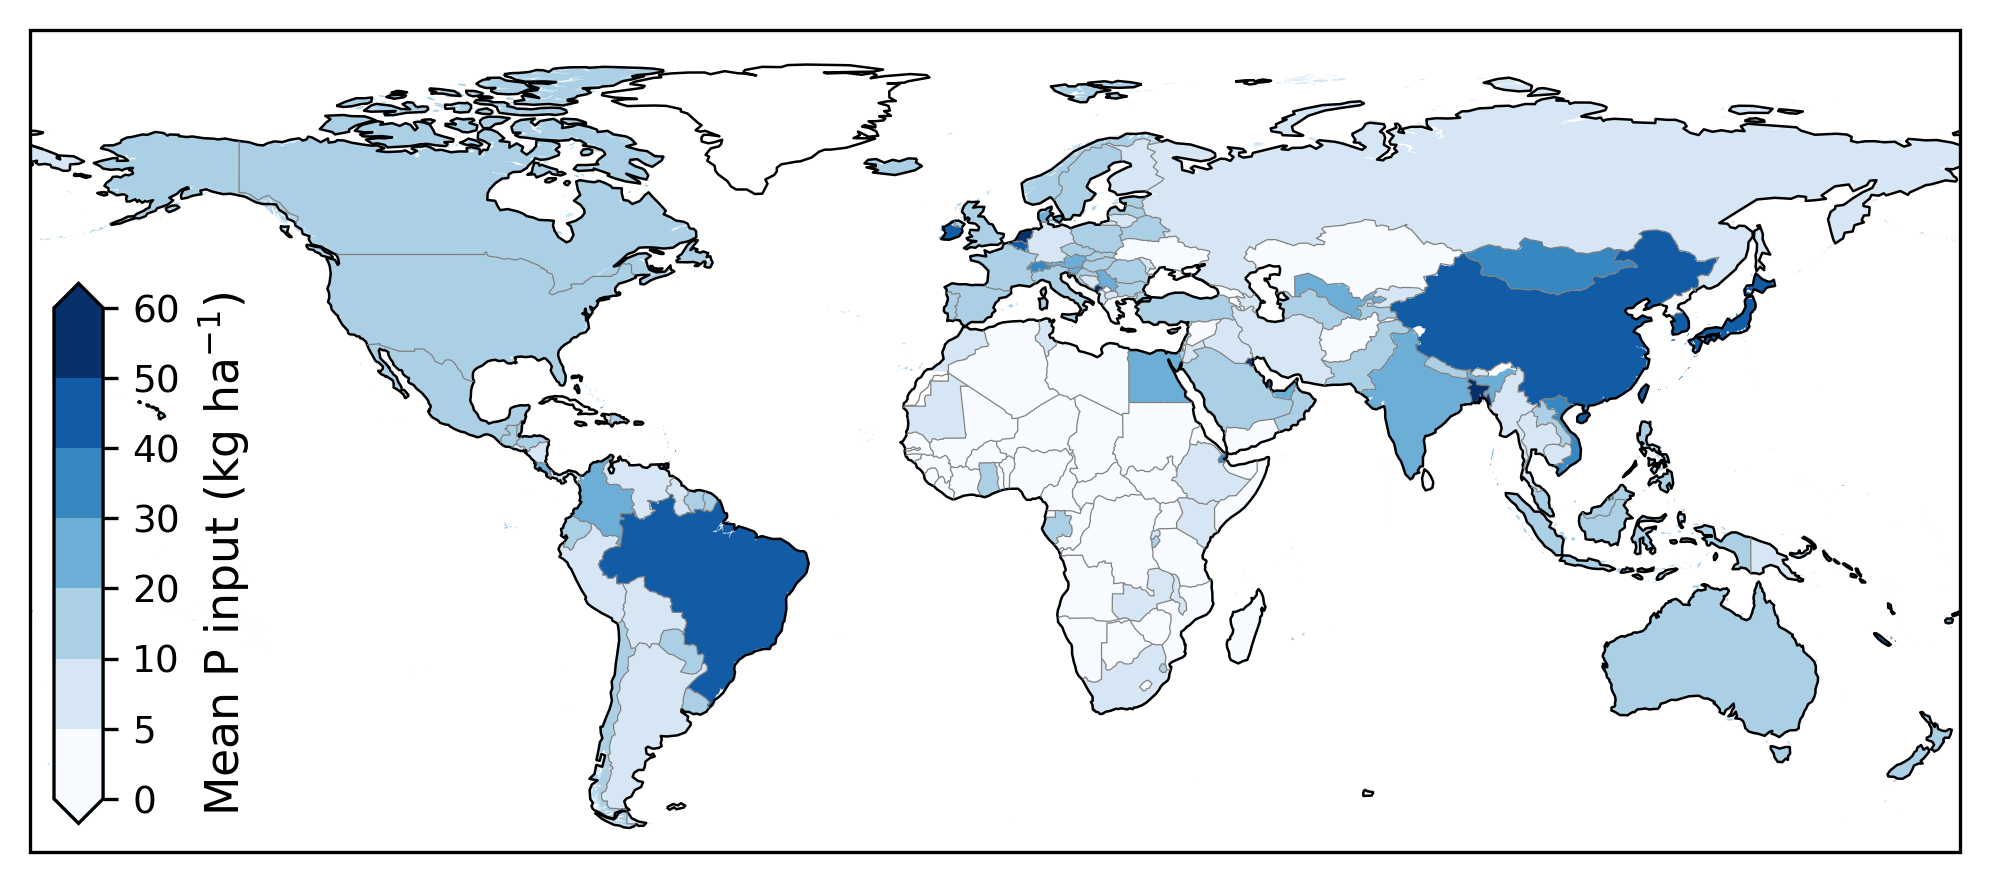

In [69]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# **创建绘图**
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300)
fig.set_size_inches(10, 5)

# **设置地图显示范围**
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

# **颜色条带**
cmaps = mpl.cm.Blues
bounds = [0, 5, 10, 20, 30, 40, 50, 60]
norm = mpl.colors.BoundaryNorm(bounds, cmaps.N)

# **绘制 GeoDataFrame**
plot = merged_gdf_bau.plot(
    column="T_P_kg/ha", cmap=cmaps, linewidth=0, edgecolor="black", 
    ax=ax, norm=norm, legend=False  # 不让 `geopandas` 自动加 legend
)

# **添加地理特征**
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)  
ax.add_feature(cfeature.BORDERS, edgecolor='grey', linewidth=0.3)

# **添加颜色条**
cb = plt.cm.ScalarMappable(norm=norm, cmap=cmaps)
cbar = fig.colorbar(cb, ax=ax, shrink=0.5, pad=0.02, orientation='vertical', extend='both', aspect=11)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Mean P input (kg ha$^{-1}$)", fontsize=11) # 如果想分成两行 需要分行的地方打\n即可
cbar.ax.set_position([0.133, 0.24, 0.5, 0.36])
#cbar.ax.set_position([0.133, 0.27, 0.3, 0.3])
# **隐藏坐标轴**
#ax.set_xticks([])
#ax.set_yticks([])
#ax.set_frame_on(False)

# **显示地图**
plt.show()


2. OPT-当前P inputs

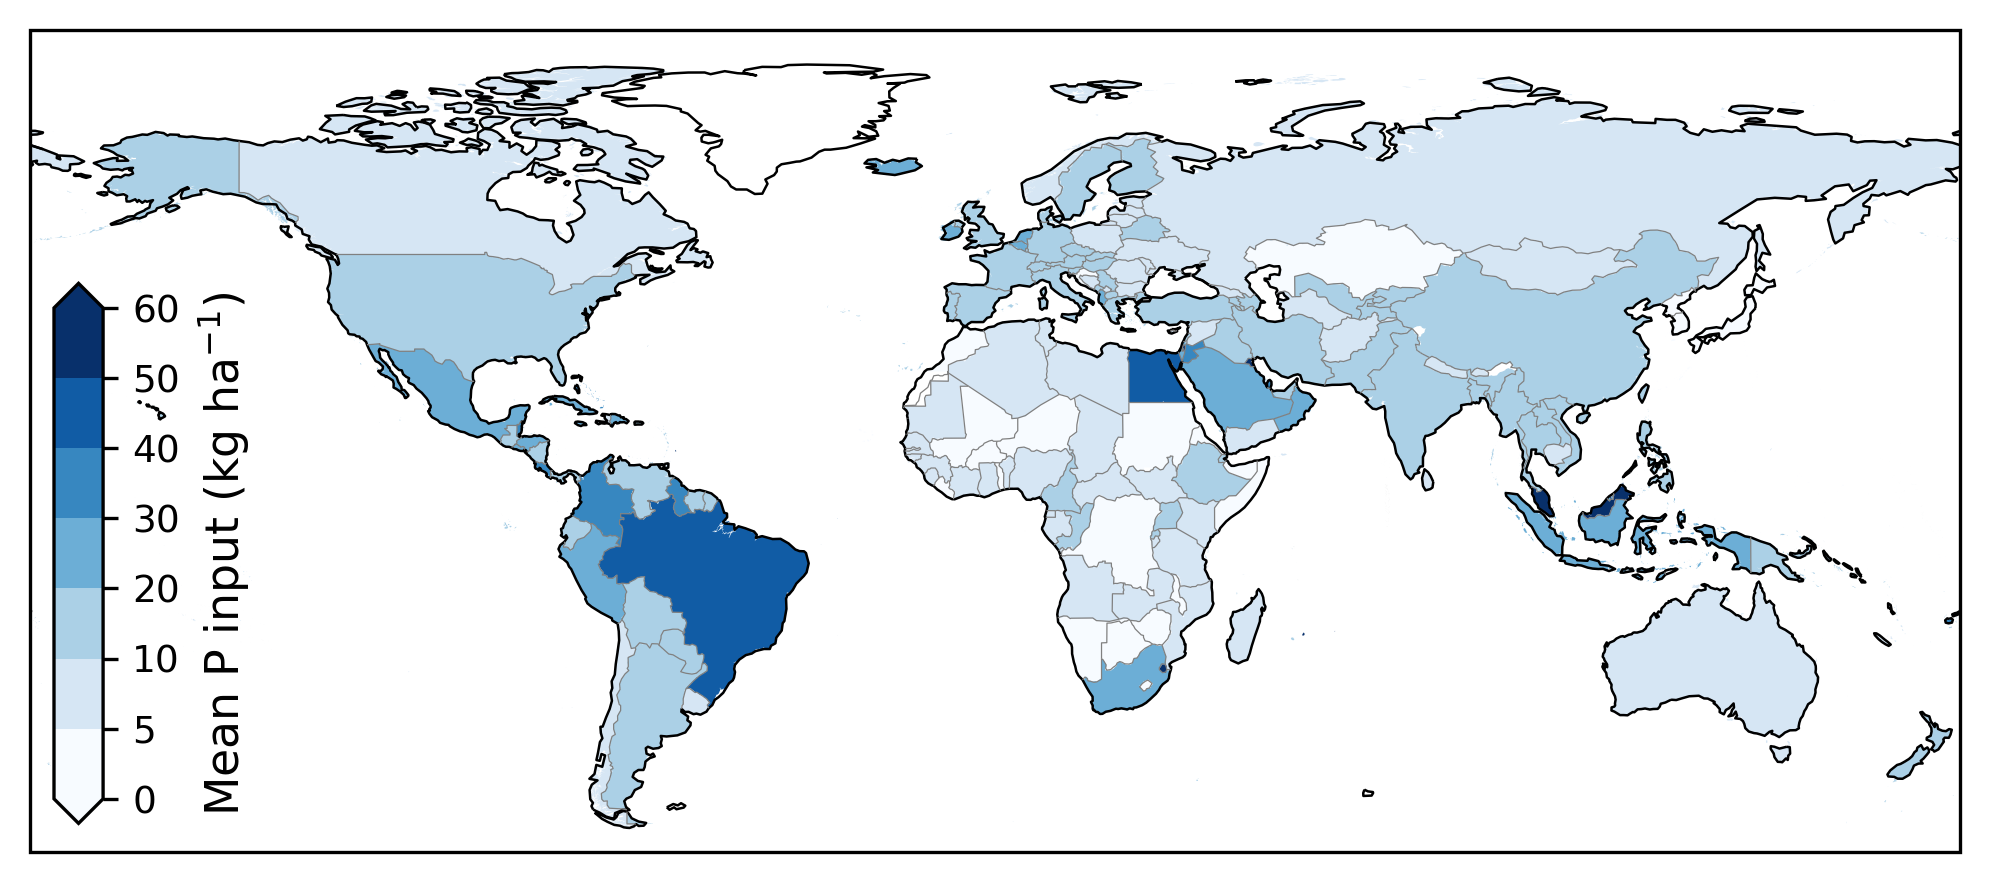

In [70]:

# **创建绘图**
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300)
fig.set_size_inches(10, 5)

# **设置地图显示范围**
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

# **颜色条带**
cmaps = mpl.cm.Blues
bounds = [0, 5, 10, 20, 30, 40, 50, 60]
norm = mpl.colors.BoundaryNorm(bounds, cmaps.N)

# **绘制 GeoDataFrame**
plot = merged_gdf_bau.plot(
    column="current_mean", cmap=cmaps, linewidth=0, edgecolor="black", 
    ax=ax, norm=norm, legend=False  # 不让 `geopandas` 自动加 legend
)

# **添加地理特征**
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)  
ax.add_feature(cfeature.BORDERS, edgecolor='grey', linewidth=0.3)

# **添加颜色条**
cb = plt.cm.ScalarMappable(norm=norm, cmap=cmaps)
cbar = fig.colorbar(cb, ax=ax, shrink=0.5, pad=0.02, orientation='vertical', extend='both', aspect=11)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Mean P input (kg ha$^{-1}$)", fontsize=11) # 如果想分成两行 需要分行的地方打\n即可
cbar.ax.set_position([0.133, 0.24, 0.5, 0.36])
#cbar.ax.set_position([0.133, 0.27, 0.3, 0.3])
# **隐藏坐标轴**
#ax.set_xticks([])
#ax.set_yticks([])
#ax.set_frame_on(False)

# **显示地图**
plt.show()


3. OPT-未来P inputs

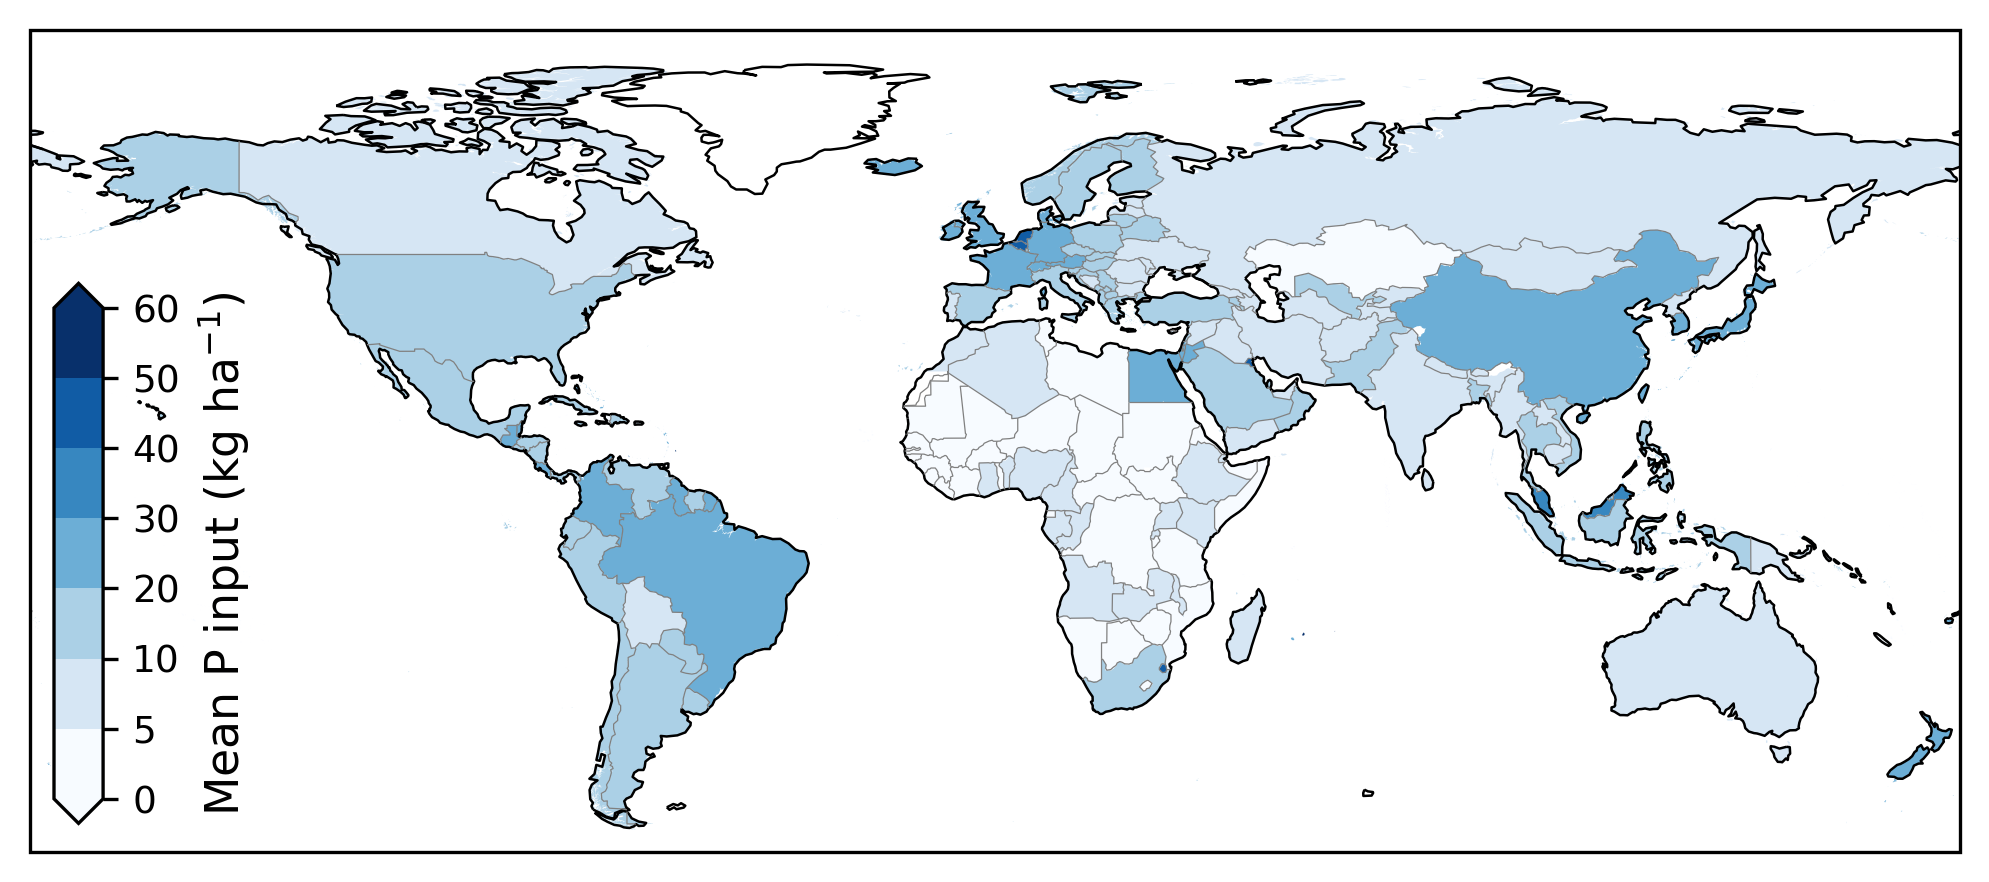

In [71]:

# **创建绘图**
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300)
fig.set_size_inches(10, 5)

# **设置地图显示范围**
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

# **颜色条带**
cmaps = mpl.cm.Blues
bounds = [0, 5, 10, 20, 30, 40, 50, 60]
norm = mpl.colors.BoundaryNorm(bounds, cmaps.N)

# **绘制 GeoDataFrame**
plot = merged_gdf_bau.plot(
    column="future_mean", cmap=cmaps, linewidth=0, edgecolor="black", 
    ax=ax, norm=norm, legend=False  # 不让 `geopandas` 自动加 legend
)

# **添加地理特征**
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)  
ax.add_feature(cfeature.BORDERS, edgecolor='grey', linewidth=0.3)

# **添加颜色条**
cb = plt.cm.ScalarMappable(norm=norm, cmap=cmaps)
cbar = fig.colorbar(cb, ax=ax, shrink=0.5, pad=0.02, orientation='vertical', extend='both', aspect=11)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Mean P input (kg ha$^{-1}$)", fontsize=11) # 如果想分成两行 需要分行的地方打\n即可
cbar.ax.set_position([0.133, 0.24, 0.5, 0.36])
#cbar.ax.set_position([0.133, 0.27, 0.3, 0.3])
# **隐藏坐标轴**
#ax.set_xticks([])
#ax.set_yticks([])
#ax.set_frame_on(False)

# **显示地图**
plt.show()

柱状图

全球当前现状

In [72]:
Current_Pfer

,NAME_EN,region,Area,C_kg/ha,C_t,M_kg/ha,M_t,Element Code,Element,Item Code,T_P_kg/ha,T_P_t,current_mean,future_mean,region_code
0,Afghanistan,Asia,Afghanistan,0.6292,5065.6333,1.5830,12744.7939,7281.0,Cropland phosphorus per unit area,5087.0,2.2122,17810.4272,9.530145,7.311460,1
1,Albania,Europe,Albania,2.2472,1542.4503,7.5879,5208.3494,7281.0,Cropland phosphorus per unit area,5087.0,9.8351,6750.7997,21.828073,15.170009,2
2,Algeria,Africa,Algeria,2.8425,24171.8400,0.5172,4397.9709,7281.0,Cropland phosphorus per unit area,5087.0,3.3597,28569.8109,9.269530,7.017402,0
3,American Samoa,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.182105,2.531454,4
4,Andorra,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.628820,10.056409,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Wallis and Futuna,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.639781,2.382936,4
198,Yemen,Asia,Yemen,0.4842,703.0631,1.8385,2669.5589,7281.0,Cropland phosphorus per unit area,5087.0,2.3227,3372.6220,8.514749,5.007101,1
199,Zambia,Africa,Zambia,6.0521,23233.8819,1.6421,6304.2075,7281.0,Cropland phosphorus per unit area,5087.0,7.6942,29538.0894,6.069883,7.875964,0
200,Zimbabwe,Africa,Zimbabwe,3.7472,11902.8000,0.9474,3009.4825,7281.0,Cropland phosphorus per unit area,5087.0,4.6946,14912.2825,4.065072,3.219262,0


In [73]:
country_region_shp = pd.read_csv('./5_Model_data/Global_data/Country_region_shp.csv')

Current_Pfer_total = Current_Pfer['T_P_t']

In [74]:
compare_P_fer = pd.DataFrame({
    'BAU': Current_Pfer_total/1000,
    'OPT_C': P_fertilizer_name['Pfer_total_all']/1000000,
    'OPT_F': P_fertilizer_name['Pfer_total_f']/1000000,
    'NAME_EN': country_region_shp['NAME_EN'],
    'region':country_region_shp['region']
})
compare_P_fer_region = compare_P_fer.groupby("region").sum(numeric_only=True).reset_index()
compare_P_fer_region

,region,BAU,OPT_C,OPT_F
0,Africa,1306.295439,1681.678095,1180.023774
1,Asia,13440.292457,8144.171382,7132.137763
2,Europe,2722.585237,1902.764475,2241.891095
3,North America,3134.379015,2194.915181,2453.782348
4,Oceania,357.497933,231.480972,212.115737
5,South America,3670.836126,3476.421968,2365.876332


In [75]:
compare_P_fer_region['BAU'].sum()

24631.886207200005

In [76]:
compare_P_fer_region['OPT_F'].sum()

15585.827048801546

In [77]:
compare_P_fer_region['OPT_C'].sum()

17631.432072819967

In [79]:
compare_P_fer_region

,region,BAU,OPT_C,OPT_F
0,Africa,1306.295439,1681.678095,1180.023774
1,Asia,13440.292457,8144.171382,7132.137763
2,Europe,2722.585237,1902.764475,2241.891095
3,North America,3134.379015,2194.915181,2453.782348
4,Oceania,357.497933,231.480972,212.115737
5,South America,3670.836126,3476.421968,2365.876332


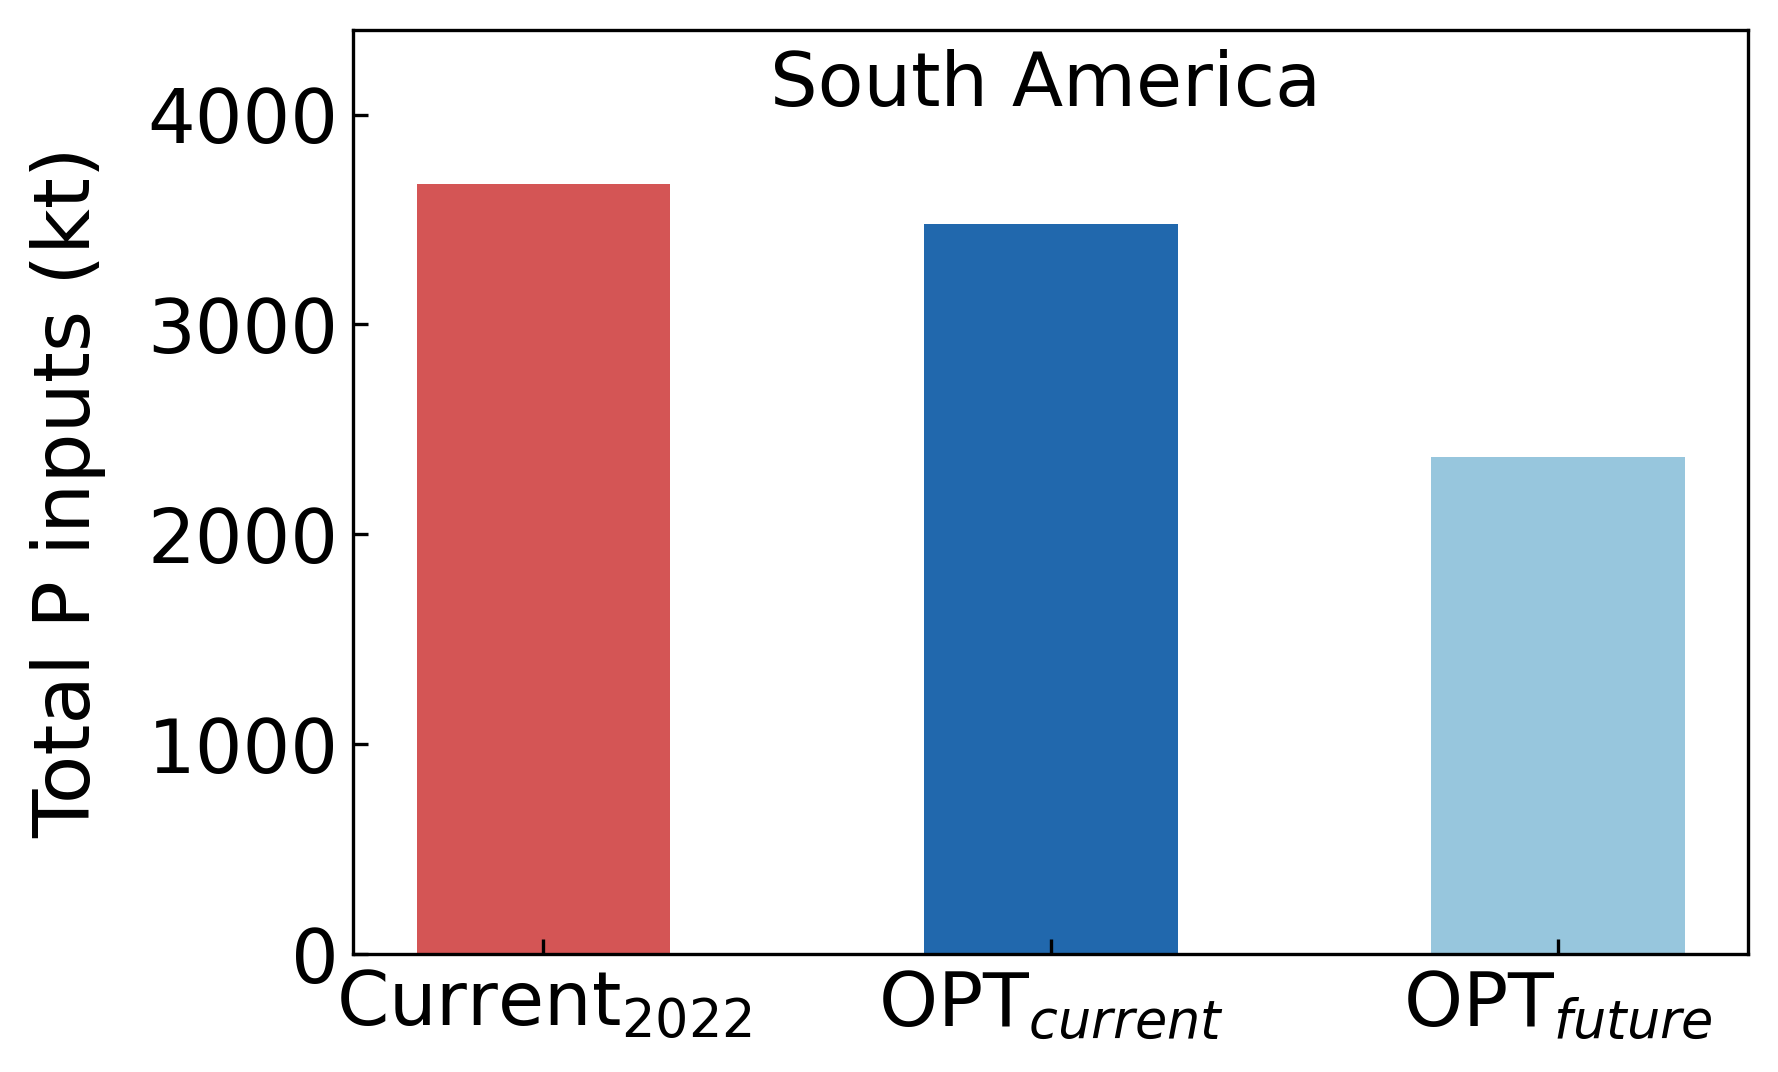

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制y刻度数量

# 选择区域
region_class = 'South America'

# 取出该区域的三值
row = compare_P_fer_region[compare_P_fer_region['region'] == region_class].iloc[0]
values = [row['BAU'], row['OPT_C'], row['OPT_F']]

# 自定义颜色
colors = ['#D45555','#2168AD', '#97C6DD']

# x轴标签（Current第二行小写2022）
xlabels = ['Current$_{2022}$', 'OPT$_{current}$', 'OPT$_{future}$']

# 画图
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
x = np.arange(3)
bar_width = 0.5

bars = ax.bar(x, values, width=bar_width, color=colors)

# x轴标签、y轴标签
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=18)
ax.set_ylabel('Total P inputs (kt)', fontsize=19, labelpad=10)
ax.tick_params(labelsize=18, direction='in')

# y轴自动调整并控制刻度数
ax.set_ylim(0, max(values)*1.2)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

# 在图中加区域名字
plt.text(plt.xlim()[1]/2.4, plt.ylim()[1]*0.9, region_class,
         fontsize=18, ha='center', va='bottom')

plt.show()


In [81]:
test = country_region_shp.merge(Current_Pfer, on="NAME_EN", how="left")
#test.to_csv('./5_Model_data/Global_data/Global_Pfer_shp.csv', index=False)

# 补充材料图片-待定的

In [82]:
# Soil-土壤变量
Sample = './3_Processed_data/1_Grid/1_Soil/0_Olsen_P/Olsen-P_10km.tif' #(mg/kg)

with rasterio.open(Sample) as src:
    band1 = src.read(1)  # 读取第一个波段
    nodata_value = src.nodata #读取Nodata
    transform = src.transform
    crs = src.crs
    nodata_value = src.nodata

    # 创建掩码，将NoData值屏蔽
    band1 = np.ma.masked_equal(band1, nodata_value)

    # 计算栅格的边界坐标
    height, width = band1.shape
    x = np.linspace(transform[2], transform[2] + transform[0] * width, width + 1)
    y = np.linspace(transform[5], transform[5] + transform[4] * height, height + 1)
    x, y = np.meshgrid(x, y)

In [83]:
dt_har_crop = pd.DataFrame({
    'rice_phy': dt_har['RICE'],
    'wheat_phy': dt_har['WHEA'],
    'maize_phy': dt_har['MAIZ'],
    'cereals_phy': dt_har[['BARL', 'PMIL', 'SMIL', 'SORG', 'OCER']].sum(axis=1),
    'cash_phy': dt_har[['SUGC', 'SUGB', 'COTT', 'OFIB', 'ACOF', 'RCOF', 'COCO', 'TEAS', 'TOBA', 'REST']].sum(axis=1),
    'pulses_phy': dt_har[['BEAN', 'CHIC', 'COWP', 'PIGE', 'LENT', 'OPUL', 'SOYB', 'GROU']].sum(axis=1),
    'roots_phy': dt_har[['POTA', 'SWPO', 'YAMS', 'CASS', 'ORTS']].sum(axis=1),
    'veg_phy': dt_har[['VEGE','CNUT', 'BANA', 'PLNT', 'TROF', 'TEMF']].sum(axis=1),
    'oil_phy': dt_har[['OILP', 'SUNF', 'RAPE', 'SESA', 'OOIL']].sum(axis=1),
    'total_phy':dt_har.sum(axis=1),
    'region':country_shp['Region'],
    'NAME_EN':country_shp['NAME_EN']
})
dt_har_crop

,rice_phy,wheat_phy,maize_phy,cereals_phy,cash_phy,pulses_phy,roots_phy,veg_phy,oil_phy,total_phy,region,NAME_EN
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,0.0,1.3,Europe,Norway
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.9,Europe,Norway
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1,0.0,1.1,Europe,Norway
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.9,Europe,Norway
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.9,Europe,Norway
...,...,...,...,...,...,...,...,...,...,...,...,...
832822,0.0,0.0,0.0,0.0,0.0,0.0,1.8,0.0,0.0,1.8,South America,Chile
832823,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.4,South America,Chile
832824,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,South America,Chile
832825,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,1.5,South America,Chile


In [84]:
# 当前
P_maize_unit = P_fertilizer['Pfer_total_maize']/dt_har_crop['maize_phy']
P_rice_unit = P_fertilizer['Pfer_total_rice']/dt_har_crop['rice_phy']
P_wheat_unit = P_fertilizer['Pfer_total_wheat']/dt_har_crop['wheat_phy']
P_cereal_unit = P_fertilizer['Pfer_total_cereal']/dt_har_crop['cereals_phy']
P_rhizome_unit = P_fertilizer['Pfer_total_rhizome']/dt_har_crop['roots_phy']
P_legume_unit = P_fertilizer['Pfer_total_legume']/dt_har_crop['pulses_phy']
P_vf_unit = P_fertilizer['Pfer_total_vf']/dt_har_crop['veg_phy']
P_oil_unit = P_fertilizer['Pfer_total_oil']/dt_har_crop['oil_phy']
P_cash_unit = P_fertilizer['Pfer_total_cash']/dt_har_crop['cash_phy']
P_mean_unit = P_fertilizer['Pfer_total_all']/dt_har_crop['total_phy']
# 未来
P_maize_unit_f = P_fertilizer['Pfer_total_maize_f']/dt_har_crop['maize_phy']
P_rice_unit_f = P_fertilizer['Pfer_total_rice_f']/dt_har_crop['rice_phy']
P_wheat_unit_f = P_fertilizer['Pfer_total_wheat_f']/dt_har_crop['wheat_phy']
P_cereal_unit_f = P_fertilizer['Pfer_total_cereal']/dt_har_crop['cereals_phy']
P_rhizome_unit_f = P_fertilizer['Pfer_total_rhizome']/dt_har_crop['roots_phy']
P_legume_unit_f = P_fertilizer['Pfer_total_legume']/dt_har_crop['pulses_phy']
P_vf_unit_f = P_fertilizer['Pfer_total_vf']/dt_har_crop['veg_phy']
P_oil_unit_f = P_fertilizer['Pfer_total_oil']/dt_har_crop['oil_phy']
P_cash_unit_f = P_fertilizer['Pfer_total_cash']/dt_har_crop['cash_phy']
P_mean_unit_f = P_fertilizer['Pfer_total_all']/dt_har_crop['total_phy']
P_mean_unit_f = P_fertilizer['Pfer_total_f']/dt_har_crop['total_phy']

In [85]:
# 恢复为原始结构的 DataFrame
# 找到原始形状的索引映射
restored_array = np.full(lssss.shape, np.nan)
restored_array[~np.ma.masked_equal(lssss, nodata_value).mask] = P_vf_unit_f
restored_df = pd.DataFrame(restored_array)

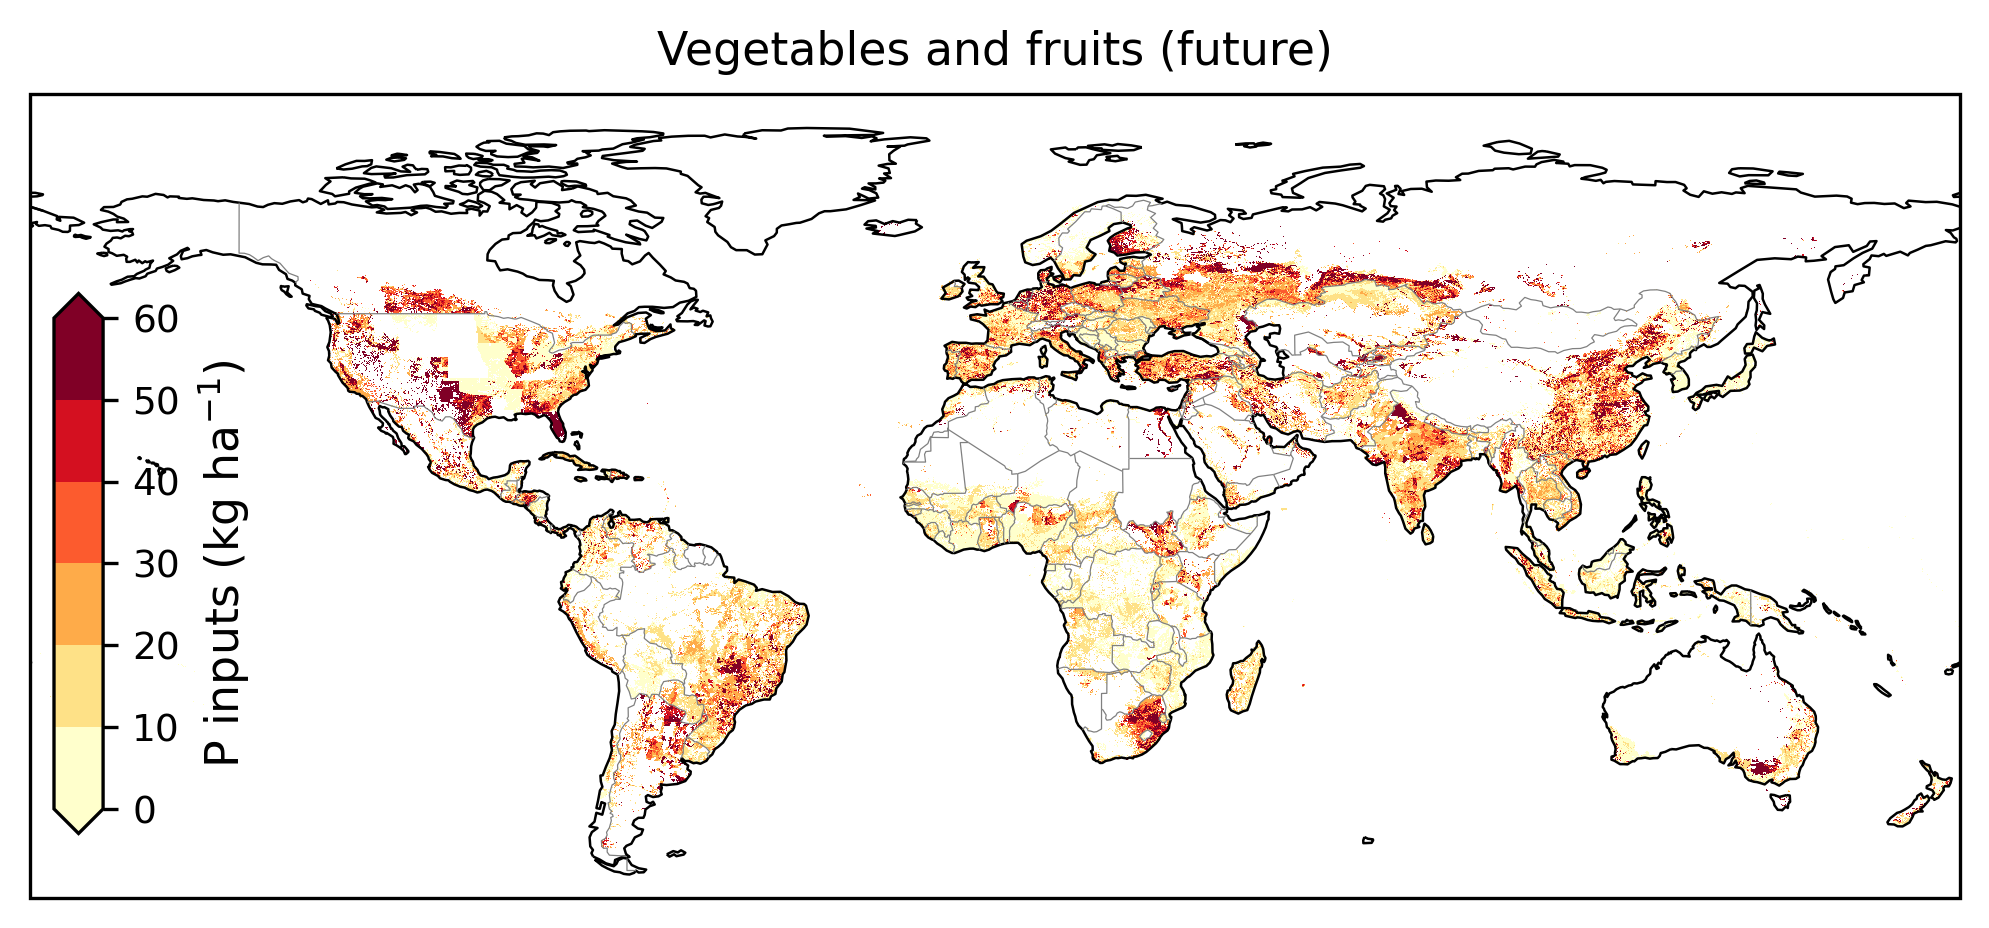

In [86]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 颜色条带
cmaps = mpl.cm.YlOrRd
# 条带范围
bounds = [ 0, 10, 20, 30, 40, 50, 60]

# 创建绘图对象
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300)
fig.set_size_inches(10, 5)

# 设置地图显示范围
extents=[-180, 180, -60, 90]
ax.set_extent(extents, crs=ccrs.PlateCarree())

norm = mpl.colors.BoundaryNorm(bounds, cmaps.N)

# 添加地理特征
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)  # 添加海岸线
ax.add_feature(cfeature.BORDERS, edgecolor='grey', linewidth=0.3)  # 添加国家边界

# 绘制栅格图
c = ax.pcolormesh(x, y, restored_df, cmap=cmaps, transform=ccrs.PlateCarree(), shading='auto', norm=norm)

# 颜色条（竖直放置在左下角）
cb = fig.colorbar(c, ax=ax, shrink=0.5, pad=0.02, orientation='vertical', extend='both', aspect=11)

# 设置颜色条刻度的字体大小
cb.ax.tick_params(labelsize=9)
cb.set_label('P inputs (kg ha$^{-1}$)', fontsize=11)
#cb.ax.yaxis.set_label_position('left') 
# 调整颜色条的位置（左下角）
cb.ax.set_position([0.133, 0.27, 0.5, 0.36])  # [左, 下, 宽度, 高度]

# 添加标题
ax.set_title('Vegetables and fruits (future)', fontsize=11, pad=7)

# 显示图像
plt.show()